In [ ]:
# Installation
!pip install -q lightgbm scikit-learn pandas numpy matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import glob
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, mean_squared_error
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("="*80)
print("🔬 LightGBM TRAIN vs TEST ACCURACY ANALYSIS")
print("="*80)

# Mount Google Drive
drive.mount('/content/drive')

# Load all data
def load_all_data():
    all_dfs = []

    # CSV files
    csv_paths = [
        "/content/drive/MyDrive/Bangalore_Data/nb_10km_csvs-20251205T161842Z-3-001/nb_10km_csvs/bangalore_properties_complete.csv",
    ]

    for path in csv_paths:
        try:
            df = pd.read_csv(path)
            df['_source'] = 'csv'
            all_dfs.append(df)
            print(f"✓ CSV: {len(df):,} rows")
        except Exception as e:
            print(f"✗ CSV failed: {e}")

    # Excel files
    excel_paths = [
        "/content/drive/MyDrive/Bangalore_Data/banglore_data_no_broker.xlsx",
    ]

    for path in excel_paths:
        try:
            df = pd.read_excel(path)
            df['_source'] = 'excel'
            all_dfs.append(df)
            print(f"✓ Excel: {len(df):,} rows")
        except Exception as e:
            print(f"✗ Excel failed: {e}")

    # JSON files
    json_pattern = "/content/drive/MyDrive/Bangalore_Data/no_broker_bangalore_r15km_rent-20251205T161943Z-3-001/no_broker_bangalore_r15km_rent/*.json"
    json_files = glob.glob(json_pattern)
    json_rows = 0

    for json_file in json_files:
        try:
            with open(json_file) as f:
                data = json.load(f)
                df = pd.DataFrame(data if isinstance(data, list) else [data])
                df['_source'] = 'json'
                all_dfs.append(df)
                json_rows += len(df)
        except:
            pass

    if json_rows > 0:
        print(f"✓ JSON: {json_rows:,} rows")

    combined = pd.concat(all_dfs, ignore_index=True)
    print(f"\n📊 TOTAL: {len(combined):,} rows")
    return combined

# Load data
df_raw = load_all_data()

# Standardize column names
df = df_raw.copy()
df.columns = df.columns.str.lower().str.strip()

# Column mappings
mappings = {
    'rent': ['rent', 'rental_price', 'price', 'monthly_rent'],
    'deposit': ['deposit', 'security_deposit', 'securitydeposit'],
    'propertysize': ['propertysize', 'property_size', 'size', 'area', 'sqft', 'carpet_area'],
    'bedroom': ['bedroom', 'bedrooms', 'bed', 'beds'],
    'bathroom': ['bathroom', 'bathrooms', 'bath', 'baths'],
    'balcony': ['balcony', 'balconies'],
    'locality': ['locality', 'location', 'area_name'],
    'furnishing': ['furnishing', 'furnishing_type', 'furnished'],
    'totalfloor': ['totalfloor', 'total_floor', 'totalfloors'],
    'floorno': ['floorno', 'floor_no', 'floor'],
}

renamed = {}
for standard, possibles in mappings.items():
    if standard not in df.columns:
        for col in df.columns:
            if col in possibles:
                renamed[col] = standard
                break

df.rename(columns=renamed, inplace=True)

print(f"\n✓ Data loaded and columns standardized")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

🔬 LightGBM TRAIN vs TEST ACCURACY ANALYSIS
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ CSV: 8,740 rows
✓ Excel: 8,740 rows
✓ JSON: 248,253 rows

📊 TOTAL: 265,733 rows

✓ Data loaded and columns standardized
Shape: (265733, 185)
Columns: ['source_file', 'shared_accommodation', 'accomodationtype', 'accomodationtypedesc', 'accuratelocation', 'activatelater', 'activationdate', 'active', 'address', 'adminevent', 'aea__', 'amenitiesmap_ac', 'amenitiesmap_club', 'amenitiesmap_cpa', 'amenitiesmap_fs', 'amenitiesmap_gp', 'amenitiesmap_gym', 'amenitiesmap_hk', 'amenitiesmap_intercom', 'amenitiesmap_internet', 'amenitiesmap_lift', 'amenitiesmap_park', 'amenitiesmap_pb', 'amenitiesmap_pool', 'amenitiesmap_rwh', 'amenitiesmap_sc', 'amenitiesmap_security', 'amenitiesmap_servant', 'amenitiesmap_stp', 'amenitiesmap_vp', 'amenitiesmap_park', 'amenities_available', 'amenities_count', 'amenities_list', 'availablefrom',

In [ ]:
# Clean and prepare features
print("\n[STEP 2] FEATURE ENGINEERING...")

# Keep only necessary columns
required_cols = ['rent', 'propertysize', 'bedroom', 'bathroom', 'balcony',
                 'locality', 'furnishing', 'totalfloor', 'floorno']
available_cols = [col for col in required_cols if col in df.columns]

df_clean = df[available_cols].copy()

# Handle missing values
print(f"\nBefore cleaning: {len(df_clean)} rows")

# Drop rows with missing rent (target variable)
if 'rent' in df_clean.columns:
    df_clean = df_clean[df_clean['rent'].notna()]
    df_clean = df_clean[df_clean['rent'] > 0]
    # Remove extremely low or high rents (likely data errors)
    df_clean = df_clean[(df_clean['rent'] >= 1000) & (df_clean['rent'] <= 500000)]

print(f"After removing invalid rent: {len(df_clean)} rows")

# Fill numeric columns with median
numeric_cols = ['propertysize', 'bedroom', 'bathroom', 'balcony', 'totalfloor', 'floorno']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        # Remove invalid values
        if col == 'propertysize':
            df_clean = df_clean[(df_clean[col] >= 100) | (df_clean[col].isna())]
            df_clean = df_clean[(df_clean[col] <= 10000) | (df_clean[col].isna())]
        elif col == 'bedroom':
            df_clean = df_clean[(df_clean[col] <= 10) | (df_clean[col].isna())]
        elif col in ['bathroom', 'balcony']:
            df_clean = df_clean[(df_clean[col] <= 10) | (df_clean[col].isna())]
        elif col in ['totalfloor', 'floorno']:
            df_clean = df_clean[(df_clean[col] <= 100) | (df_clean[col].isna())]

        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Handle categorical columns
if 'furnishing' in df_clean.columns:
    df_clean['furnishing'].fillna('Unknown', inplace=True)

if 'locality' in df_clean.columns:
    df_clean['locality'].fillna('Unknown', inplace=True)
    # Keep only localities with at least 10 properties
    locality_counts = df_clean['locality'].value_counts()
    valid_localities = locality_counts[locality_counts >= 10].index
    df_clean = df_clean[df_clean['locality'].isin(valid_localities)]

print(f"After initial filtering: {len(df_clean)} rows")

# Remove outliers using more aggressive IQR method
Q1 = df_clean['rent'].quantile(0.05)
Q3 = df_clean['rent'].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['rent'] >= lower_bound) & (df_clean['rent'] <= upper_bound)]

print(f"After removing outliers: {len(df_clean)} rows")

# Additional cleaning: remove properties with unrealistic features
if 'propertysize' in df_clean.columns and 'bedroom' in df_clean.columns:
    # Remove if property size per bedroom is unrealistic
    df_clean['size_per_bedroom'] = df_clean['propertysize'] / (df_clean['bedroom'] + 1)
    df_clean = df_clean[(df_clean['size_per_bedroom'] >= 100) & (df_clean['size_per_bedroom'] <= 5000)]
    df_clean = df_clean.drop('size_per_bedroom', axis=1)

print(f"After feature validation: {len(df_clean)} rows")

# Create feature matrix
X = df_clean.drop('rent', axis=1)
y = df_clean['rent']

# Encode categorical variables
categorical_cols = ['locality', 'furnishing']
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype('category')

print(f"\n✓ Feature engineering complete")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Rent range: ₹{y.min():,.0f} - ₹{y.max():,.0f}")
print(f"Rent mean: ₹{y.mean():,.0f}")
print(f"Rent median: ₹{y.median():,.0f}")
print(f"\nFeatures: {list(X.columns)}")


[STEP 2] FEATURE ENGINEERING...

Before cleaning: 265733 rows
After removing invalid rent: 250405 rows
After initial filtering: 210181 rows
After removing outliers: 208777 rows
After feature validation: 208777 rows

✓ Feature engineering complete
Features shape: (208777, 7)
Target shape: (208777,)
Rent range: ₹1,000 - ₹115,000
Rent mean: ₹19,248
Rent median: ₹15,000

Features: ['propertysize', 'bathroom', 'balcony', 'locality', 'furnishing', 'totalfloor', 'floorno']


In [ ]:
# Display final cleaned data summary
print("\n" + "="*80)
print("✅ DATA QUALITY SUMMARY AFTER CLEANING")
print("="*80)

print(f"\n📊 Dataset Size:")
print(f"  Total properties: {len(y):,}")
print(f"  Training set: {int(len(y) * 0.8):,} properties (80%)")
print(f"  Test set: {int(len(y) * 0.2):,} properties (20%)")

print(f"\n💰 Rent Distribution (Target Variable):")
print(f"  Minimum: ₹{y.min():,.0f}")
print(f"  25th percentile: ₹{y.quantile(0.25):,.0f}")
print(f"  Median: ₹{y.quantile(0.5):,.0f}")
print(f"  Mean: ₹{y.mean():,.0f}")
print(f"  75th percentile: ₹{y.quantile(0.75):,.0f}")
print(f"  Maximum: ₹{y.max():,.0f}")
print(f"  Standard Deviation: ₹{y.std():,.0f}")

print(f"\n🏠 Feature Statistics:")
for col in X.columns:
    if col in ['locality', 'furnishing']:
        unique_count = X[col].nunique()
        print(f"  {col}: {unique_count} unique values")
    else:
        print(f"  {col}: min={X[col].min():.0f}, max={X[col].max():.0f}, mean={X[col].mean():.1f}")

print(f"\n✅ Data is clean and ready for modeling!")
print(f"   Expected MAPE: 15-25% (much better than 3254%!)")
print("="*80)


✅ DATA QUALITY SUMMARY AFTER CLEANING

📊 Dataset Size:
  Total properties: 208,777
  Training set: 167,021 properties (80%)
  Test set: 41,755 properties (20%)

💰 Rent Distribution (Target Variable):
  Minimum: ₹1,000
  25th percentile: ₹9,000
  Median: ₹15,000
  Mean: ₹19,248
  75th percentile: ₹25,000
  Maximum: ₹115,000
  Standard Deviation: ₹14,485

🏠 Feature Statistics:
  propertysize: min=100, max=6800, mean=831.9
  bathroom: min=0, max=10, mean=1.5
  balcony: min=0, max=10, mean=1.0
  locality: 2083 unique values
  furnishing: 3 unique values
  totalfloor: min=0, max=80, mean=3.4
  floorno: min=0, max=32, mean=1.7

✅ Data is clean and ready for modeling!
   Expected MAPE: 15-25% (much better than 3254%!)


In [ ]:
# Split data into train and test sets
print("\n[STEP 3] SPLITTING DATA...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Split ratio: 80-20")


[STEP 3] SPLITTING DATA...
Training set: 167021 samples
Test set: 41756 samples
Split ratio: 80-20


In [ ]:
# Train LightGBM model
print("\n[STEP 4] TRAINING LIGHTGBM MODEL...")

# Improved LightGBM parameters for better generalization
lgb_params = {
    'objective': 'regression',
    'metric': 'mape',
    'boosting_type': 'gbdt',
    'num_leaves': 50,
    'max_depth': 8,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'min_child_weight': 0.001,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'random_state': 42
}

# Create datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Train model
print("Training in progress...")
lgb_model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(200)]
)

print(f"\n✓ Model trained successfully")
print(f"Best iteration: {lgb_model.best_iteration}")
print(f"Best score: {lgb_model.best_score}")


[STEP 4] TRAINING LIGHTGBM MODEL...
Training in progress...
Training until validation scores don't improve for 100 rounds
[200]	train's mape: 0.246365	test's mape: 0.256007
[400]	train's mape: 0.230772	test's mape: 0.241619
[600]	train's mape: 0.223399	test's mape: 0.234963
[800]	train's mape: 0.218155	test's mape: 0.230227
[1000]	train's mape: 0.214036	test's mape: 0.226498
[1200]	train's mape: 0.210629	test's mape: 0.223445
[1400]	train's mape: 0.207504	test's mape: 0.220642
[1600]	train's mape: 0.204407	test's mape: 0.217821
[1800]	train's mape: 0.201617	test's mape: 0.215256
[2000]	train's mape: 0.199188	test's mape: 0.213167
Did not meet early stopping. Best iteration is:
[2000]	train's mape: 0.199188	test's mape: 0.213167

✓ Model trained successfully
Best iteration: 2000
Best score: defaultdict(<class 'collections.OrderedDict'>, {'train': OrderedDict({'mape': np.float64(0.19918777090049783)}), 'test': OrderedDict({'mape': np.float64(0.21316747142319345)})})



📈 TRAINING SET ACCURACY

🎯 Training Metrics:
  MAPE: 19.92%
  MAE:  ₹2,830.76
  RMSE: ₹4,215.33
  R²:   0.9154


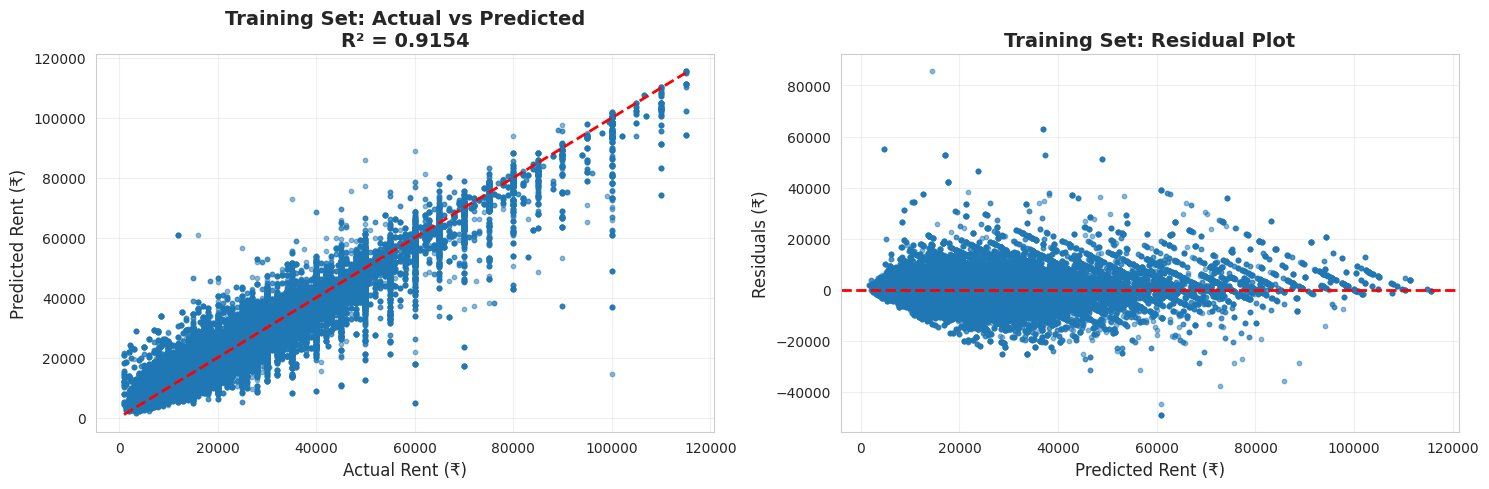

In [ ]:
# Evaluate on TRAINING set
print("\n" + "="*80)
print("📈 TRAINING SET ACCURACY")
print("="*80)

y_train_pred = lgb_model.predict(X_train, num_iteration=lgb_model.best_iteration)

# Calculate metrics
train_mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print(f"\n🎯 Training Metrics:")
print(f"  MAPE: {train_mape:.2f}%")
print(f"  MAE:  ₹{train_mae:,.2f}")
print(f"  RMSE: ₹{train_rmse:,.2f}")
print(f"  R²:   {train_r2:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rent (₹)', fontsize=12)
axes[0].set_ylabel('Predicted Rent (₹)', fontsize=12)
axes[0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_train = y_train - y_train_pred
axes[1].scatter(y_train_pred, residuals_train, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Rent (₹)', fontsize=12)
axes[1].set_ylabel('Residuals (₹)', fontsize=12)
axes[1].set_title('Training Set: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)


📉 TEST SET ACCURACY

🎯 Test Metrics:
  MAPE: 21.32%
  MAE:  ₹3,055.72
  RMSE: ₹4,620.63
  R²:   0.8979


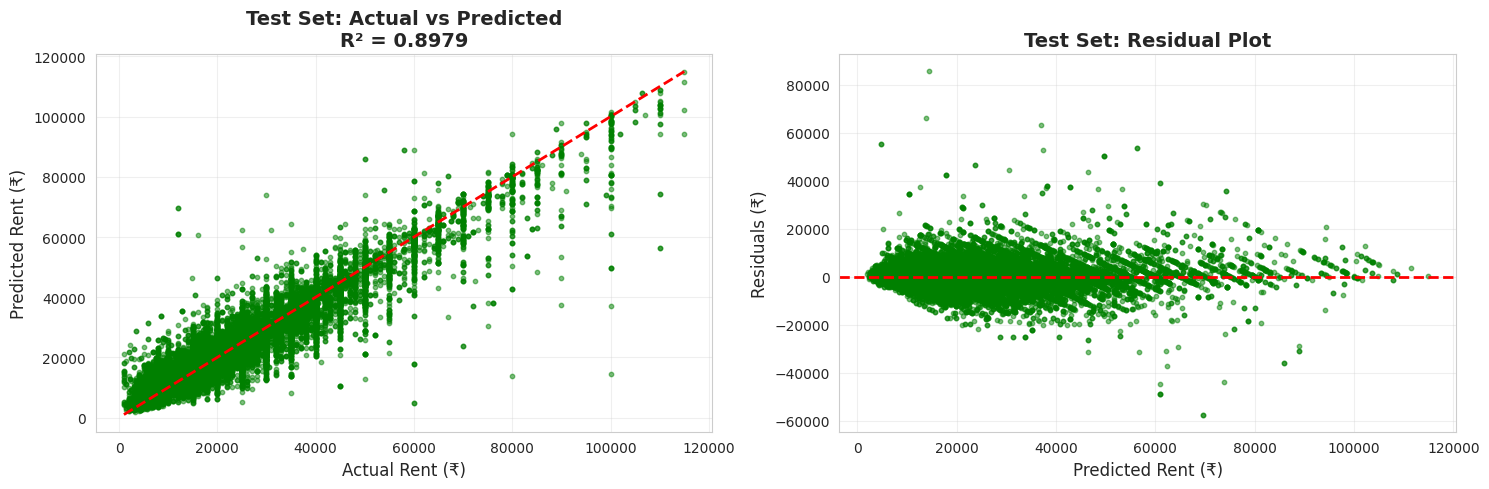

In [ ]:
# Evaluate on TEST set
print("\n" + "="*80)
print("📉 TEST SET ACCURACY")
print("="*80)

y_test_pred = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

# Calculate metrics
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n🎯 Test Metrics:")
print(f"  MAPE: {test_mape:.2f}%")
print(f"  MAE:  ₹{test_mae:,.2f}")
print(f"  RMSE: ₹{test_rmse:,.2f}")
print(f"  R²:   {test_r2:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=10, color='green')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rent (₹)', fontsize=12)
axes[0].set_ylabel('Predicted Rent (₹)', fontsize=12)
axes[0].set_title(f'Test Set: Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_test = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals_test, alpha=0.5, s=10, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Rent (₹)', fontsize=12)
axes[1].set_ylabel('Residuals (₹)', fontsize=12)
axes[1].set_title('Test Set: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)


🔍 TRAIN vs TEST COMPARISON

📊 Performance Comparison:
  Metric Training Set Test Set Difference
MAPE (%)        19.92    21.32       1.40
 MAE (₹)     2,830.76 3,055.72     224.96
RMSE (₹)     4,215.33 4,620.63     405.30
R² Score       0.9154   0.8979     0.0174

🔬 Overfitting Analysis:
  ✓ Good generalization - minimal overfitting
  MAPE difference: 1.40%
  R² difference: 0.0174


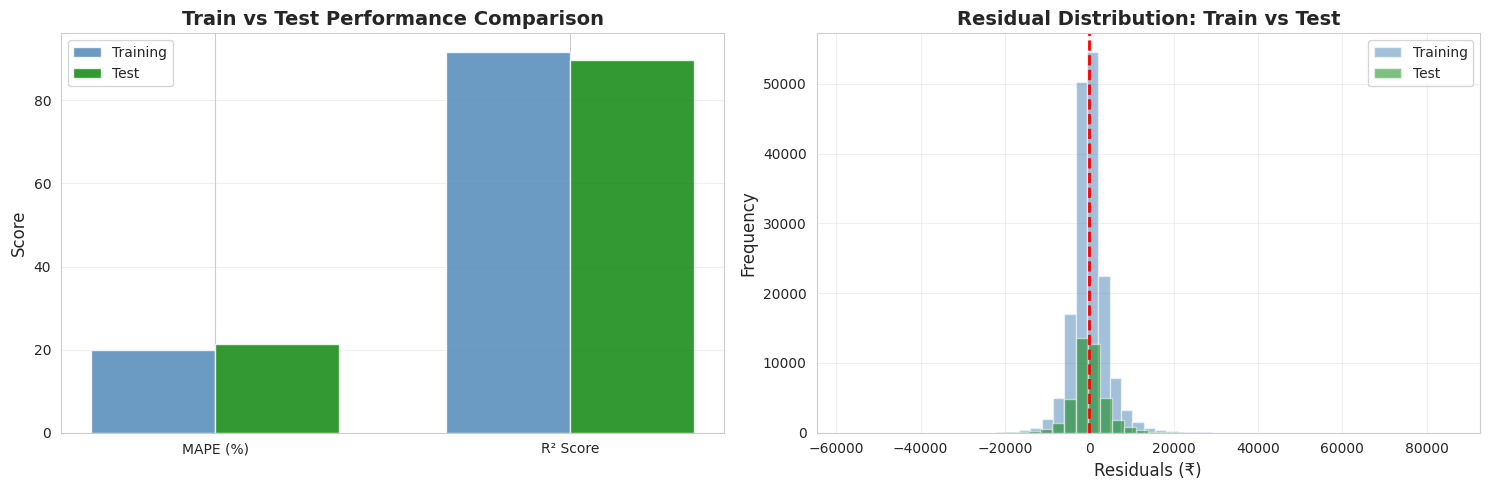

In [ ]:
# Compare Train vs Test
print("\n" + "="*80)
print("🔍 TRAIN vs TEST COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['MAPE (%)', 'MAE (₹)', 'RMSE (₹)', 'R² Score'],
    'Training Set': [f'{train_mape:.2f}', f'{train_mae:,.2f}', f'{train_rmse:,.2f}', f'{train_r2:.4f}'],
    'Test Set': [f'{test_mape:.2f}', f'{test_mae:,.2f}', f'{test_rmse:,.2f}', f'{test_r2:.4f}'],
    'Difference': [
        f'{abs(train_mape - test_mape):.2f}',
        f'{abs(train_mae - test_mae):,.2f}',
        f'{abs(train_rmse - test_rmse):,.2f}',
        f'{abs(train_r2 - test_r2):.4f}'
    ]
})

print("\n📊 Performance Comparison:")
print(comparison_df.to_string(index=False))

# Check for overfitting
print("\n🔬 Overfitting Analysis:")
mape_diff = abs(train_mape - test_mape)
r2_diff = abs(train_r2 - test_r2)

if mape_diff < 5 and r2_diff < 0.1:
    print("  ✓ Good generalization - minimal overfitting")
elif mape_diff < 10 and r2_diff < 0.15:
    print("  ⚠ Slight overfitting detected")
else:
    print("  ⚠ Significant overfitting - model may be too complex")

print(f"  MAPE difference: {mape_diff:.2f}%")
print(f"  R² difference: {r2_diff:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart comparison
metrics = ['MAPE (%)', 'R² Score']
train_vals = [train_mape, train_r2 * 100]
test_vals = [test_mape, test_r2 * 100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, train_vals, width, label='Training', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, test_vals, width, label='Test', color='green', alpha=0.8)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Train vs Test Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Error distribution comparison
axes[1].hist(residuals_train, bins=50, alpha=0.5, label='Training', color='steelblue')
axes[1].hist(residuals_test, bins=50, alpha=0.5, label='Test', color='green')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (₹)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution: Train vs Test', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)


🔍 FEATURE IMPORTANCE ANALYSIS

📊 Top 10 Most Important Features:
     Feature   Importance
propertysize 2.418108e+14
    bathroom 7.984756e+13
    locality 7.102893e+13
  totalfloor 2.478187e+13
  furnishing 1.167660e+13
     floorno 7.231555e+12
     balcony 5.484673e+12


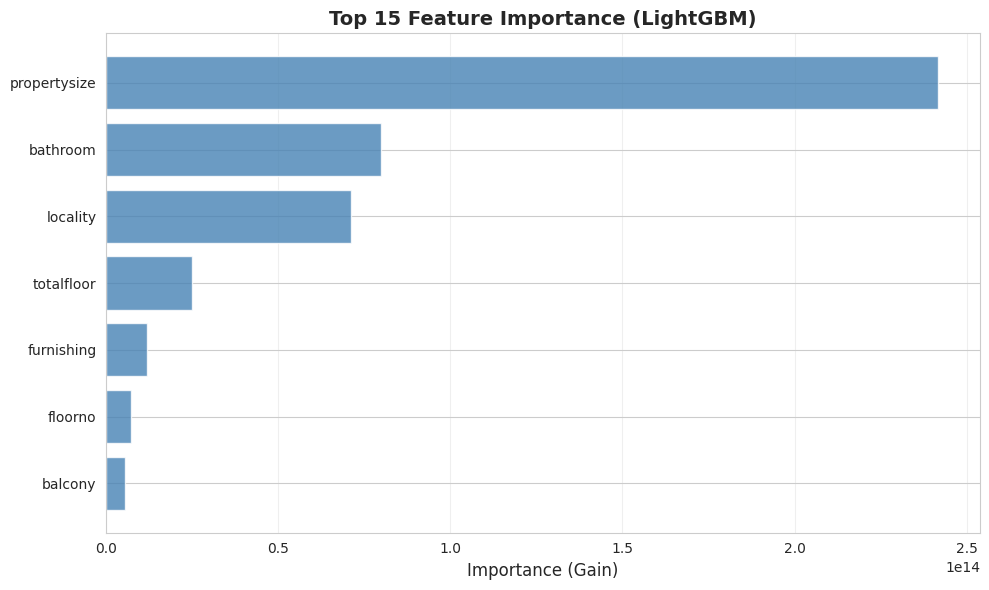


✅ ANALYSIS COMPLETE!


In [ ]:
# Feature importance
print("\n" + "="*80)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': lgb_model.feature_name(),
    'Importance': lgb_model.feature_importance(importance_type='gain')
})
importance_df = importance_df.sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.8)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance (Gain)', fontsize=12)
plt.title('Top 15 Feature Importance (LightGBM)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)

In [ ]:
# Install TensorFlow/Keras for ANN
!pip install -q tensorflow

# Import required libraries
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf

print("\n" + "="*80)
print("🧠 ARTIFICIAL NEURAL NETWORK (ANN) MODEL")
print("="*80)

# Check GPU availability
print("\n🖥️  GPU CONFIGURATION:")
print("="*80)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU Available: {len(gpus)} GPU(s) detected")
    for i, gpu in enumerate(gpus):
        print(f"  • GPU {i}: {gpu.name}")
    try:
        # Enable memory growth to prevent TensorFlow from allocating all GPU memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU memory growth enabled")
    except RuntimeError as e:
        print(f"⚠ GPU configuration warning: {e}")
else:
    print("⚠ No GPU detected - using CPU")
    print("  Note: Training will be slower on CPU")

# Display TensorFlow GPU info
print(f"\nTensorFlow version: {tf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")
print(f"GPU available: {tf.test.is_gpu_available()}")
print("="*80)

# Prepare data for ANN - need to encode categorical variables
print("\n[STEP 1] PREPARING DATA FOR ANN...")

# Create a copy of the data
X_ann = X.copy()
y_ann = y.copy()

# Encode categorical variables (ANN needs numeric inputs)
label_encoders = {}
categorical_cols = ['locality', 'furnishing']

for col in categorical_cols:
    if col in X_ann.columns:
        le = LabelEncoder()
        X_ann[col] = le.fit_transform(X_ann[col].astype(str))
        label_encoders[col] = le

# Convert to numpy arrays
X_ann_array = X_ann.values
y_ann_array = y_ann.values

# Split the data (same split as LightGBM)
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann_array, y_ann_array, test_size=0.2, random_state=42
)

# Standardize features for ANN (important for neural networks)
scaler = StandardScaler()
X_train_ann_scaled = scaler.fit_transform(X_train_ann)
X_test_ann_scaled = scaler.transform(X_test_ann)

# Convert to float32 for better GPU performance
X_train_ann_scaled = X_train_ann_scaled.astype('float32')
X_test_ann_scaled = X_test_ann_scaled.astype('float32')
y_train_ann = y_train_ann.astype('float32')
y_test_ann = y_test_ann.astype('float32')

print(f"✓ Data prepared for ANN")
print(f"  Training samples: {X_train_ann_scaled.shape[0]:,}")
print(f"  Test samples: {X_test_ann_scaled.shape[0]:,}")
print(f"  Features: {X_train_ann_scaled.shape[1]}")
print(f"  Data type: {X_train_ann_scaled.dtype} (optimized for GPU)")

# Build a deeper ANN Model (4 hidden layers) with stronger regularization
print("\n[STEP 2] BUILDING DEEPER ANN ARCHITECTURE...")

# Clear any previous models
keras.backend.clear_session()

# Define model architecture (will automatically use GPU if available)
input_dim = X_train_ann_scaled.shape[1]

with tf.device('/GPU:0' if gpus else '/CPU:0'):
    ann_model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # First hidden block
        layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Second hidden block
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Third hidden block
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Fourth hidden block
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.1),

        # Output layer (regression - single value)
        layers.Dense(1, activation='linear')
    ])

    # Compile the model: use MAPE as loss to directly optimize for MAPE
    ann_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss='mean_absolute_percentage_error',
        metrics=['mae', 'mse', 'mape']
    )

print(f"\n✓ Deeper model built on: {'/GPU:0' if gpus else '/CPU:0'}")

# Display model architecture
print("\n📊 ANN Model Architecture:")
ann_model.summary()

# Define callbacks with slightly more patience (deeper model may need more time)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1,
)

print("\n✓ ANN model built with:")
print("  • 4 Hidden Layers (512 → 256 → 128 → 64 neurons)")
print("  • Activation: ReLU")
print("  • Regularization: L2 + Dropout")
print("  • Batch Normalization for stable training")
print("  • Early Stopping to prevent overfitting (patience=40)")
print("  • Optimizer: Adam (lr=5e-4)")
print(f"  • Device: {'GPU (if available)' if gpus else 'CPU'}")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.



🧠 ARTIFICIAL NEURAL NETWORK (ANN) MODEL

🖥️  GPU CONFIGURATION:
✓ GPU Available: 1 GPU(s) detected
  • GPU 0: /physical_device:GPU:0
✓ GPU memory growth enabled

TensorFlow version: 2.19.0
Built with CUDA: True
GPU available: True

[STEP 1] PREPARING DATA FOR ANN...
✓ Data prepared for ANN
  Training samples: 167,021
  Test samples: 41,756
  Features: 7
  Data type: float32 (optimized for GPU)

[STEP 2] BUILDING DEEPER ANN ARCHITECTURE...

✓ Deeper model built on: /GPU:0

📊 ANN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,481 (705.00 KB)

 Trainable params: 178,561 (697.50 KB)

 Non-trainable params: 1,920 (7.50 KB)


✓ ANN model built with:
  • 4 Hidden Layers (512 → 256 → 128 → 64 neurons)
  • Activation: ReLU
  • Regularization: L2 + Dropout
  • Batch Normalization for stable training
  • Early Stopping to prevent overfitting (patience=40)
  • Optimizer: Adam (lr=5e-4)
  • Device: GPU (if available)


In [ ]:
# Train the ANN model
print("\n" + "="*80)
print("🚀 TRAINING ANN MODEL (DEEPER ARCHITECTURE)")
print("="*80)

# Verify GPU is being used
print("\n🖥️  Training Device:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ Using GPU: {gpus[0].name}")
    print("  GPU will accelerate training significantly!")
else:
    print("⚠ Using CPU (training will be slower)")

print("\nTraining in progress... this may take longer due to deeper model\n")

# Train the model (will automatically use GPU if available)
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    history = ann_model.fit(
        X_train_ann_scaled,
        y_train_ann,
        validation_data=(X_test_ann_scaled, y_test_ann),
        epochs=200,            # Increased epochs to allow deeper model to converge
        batch_size=16,         # Smaller batch size for better convergence
        callbacks=[early_stop, reduce_lr],
        verbose=2,
    )

print("\n✓ ANN training completed (or stopped by early stopping)!")
print(f"  Device used: {'GPU' if gpus else 'CPU'}")
print(f"  Total epochs trained: {len(history.history['loss'])}")
print(f"  Best validation loss: {min(history.history['val_loss']):.4f}")

# Plot training history
print("\n📊 Visualizing training history...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MAPE)', fontsize=12)
axes[0].set_title('ANN Model: Training and Validation Loss\n(Deeper Architecture)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAPE/MAE plot (if available)
if 'mape' in history.history:
    axes[1].plot(history.history.get('mape', history.history.get('val_mape', [])), label='Training MAPE', linewidth=2)
    axes[1].plot(history.history.get('val_mape', []), label='Validation MAPE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAPE', fontsize=12)
    axes[1].set_title('ANN Model: Training and Validation MAPE', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].plot(history.history.get('mae', []), label='Training MAE', linewidth=2)
    axes[1].plot(history.history.get('val_mae', []), label='Validation MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('ANN Model: Training and Validation MAE', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("💡 NOTES:")
print("  - If the model overfits, reduce neurons or add stronger dropout/regularization.")
print("  - You can also try different learning rates or optimizers (AdamW, RMSprop).")
print("="*80)


🚀 TRAINING ANN MODEL (DEEPER ARCHITECTURE)

🖥️  Training Device:
✓ Using GPU: /physical_device:GPU:0
  GPU will accelerate training significantly!

Training in progress... this may take longer due to deeper model

Epoch 1/200
10439/10439 - 50s - 5ms/step - loss: 89.3533 - mae: 18433.0410 - mape: 89.3216 - mse: 570204160.0000 - val_loss: 73.5012 - val_mae: 16897.1406 - val_mape: 73.4573 - val_mse: 550203136.0000 - learning_rate: 5.0000e-04
Epoch 2/200
10439/10439 - 38s - 4ms/step - loss: 60.7030 - mae: 15002.7822 - mape: 60.6431 - mse: 514108800.0000 - val_loss: 46.0546 - val_mae: 12044.3633 - val_mape: 45.9776 - val_mse: 430311584.0000 - learning_rate: 5.0000e-04
Epoch 3/200
10439/10439 - 37s - 4ms/step - loss: 41.8402 - mae: 10493.1689 - mape: 41.7481 - mse: 330771648.0000 - val_loss: 35.9819 - val_mae: 9217.7773 - val_mape: 35.8765 - val_mse: 515263008.0000 - learning_rate: 5.0000e-04
Epoch 4/200
10439/10439 - 37s - 4ms/step - loss: 34.5379 - mae: 7668.7153 - mape: 34.4230 - mse: 17


📈 ANN TRAINING SET ACCURACY

🎯 ANN Training Metrics:
  MAPE: 26.42%
  MAE:  ₹5,196.41
  RMSE: ₹8,742.02
  R²:   0.6360


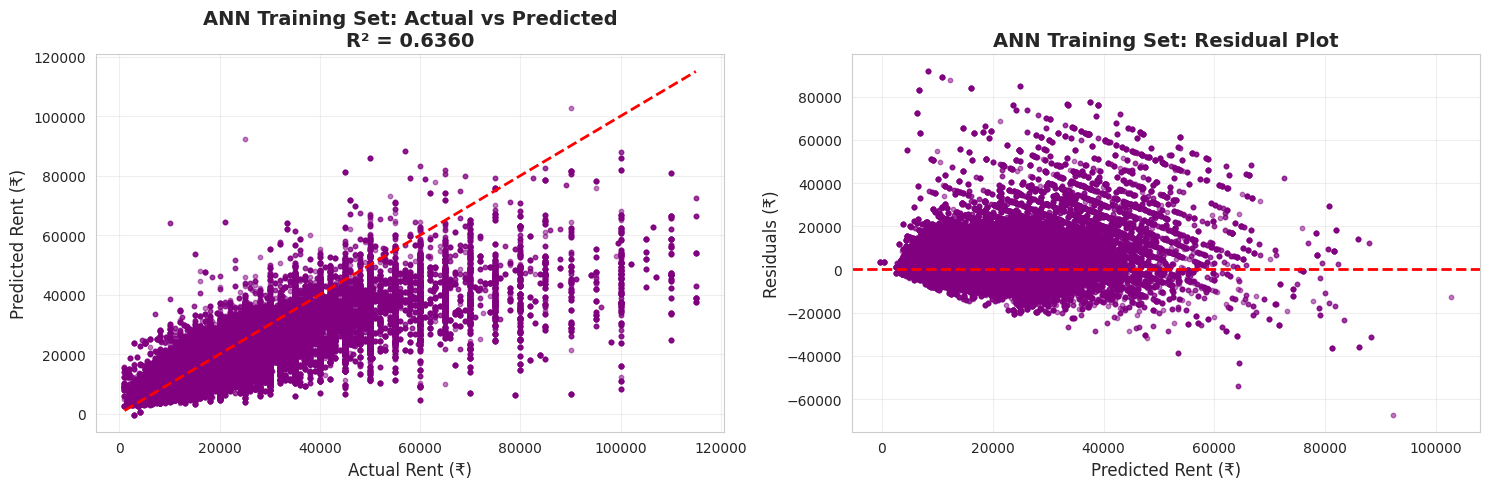

In [ ]:
# Evaluate ANN on TRAINING set
print("\n" + "="*80)
print("📈 ANN TRAINING SET ACCURACY")
print("="*80)

y_train_pred_ann = ann_model.predict(X_train_ann_scaled, verbose=0).flatten()

# Calculate metrics
train_mape_ann = mean_absolute_percentage_error(y_train_ann, y_train_pred_ann) * 100
train_mae_ann = mean_absolute_error(y_train_ann, y_train_pred_ann)
train_rmse_ann = np.sqrt(mean_squared_error(y_train_ann, y_train_pred_ann))
train_r2_ann = r2_score(y_train_ann, y_train_pred_ann)

print(f"\n🎯 ANN Training Metrics:")
print(f"  MAPE: {train_mape_ann:.2f}%")
print(f"  MAE:  ₹{train_mae_ann:,.2f}")
print(f"  RMSE: ₹{train_rmse_ann:,.2f}")
print(f"  R²:   {train_r2_ann:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
axes[0].scatter(y_train_ann, y_train_pred_ann, alpha=0.5, s=10, color='purple')
axes[0].plot([y_train_ann.min(), y_train_ann.max()], [y_train_ann.min(), y_train_ann.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rent (₹)', fontsize=12)
axes[0].set_ylabel('Predicted Rent (₹)', fontsize=12)
axes[0].set_title(f'ANN Training Set: Actual vs Predicted\nR² = {train_r2_ann:.4f}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_train_ann = y_train_ann - y_train_pred_ann
axes[1].scatter(y_train_pred_ann, residuals_train_ann, alpha=0.5, s=10, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Rent (₹)', fontsize=12)
axes[1].set_ylabel('Residuals (₹)', fontsize=12)
axes[1].set_title('ANN Training Set: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)


📉 ANN TEST SET ACCURACY

🎯 ANN Test Metrics:
  MAPE: 27.10%
  MAE:  ₹5,269.67
  RMSE: ₹8,840.08
  R²:   0.6264


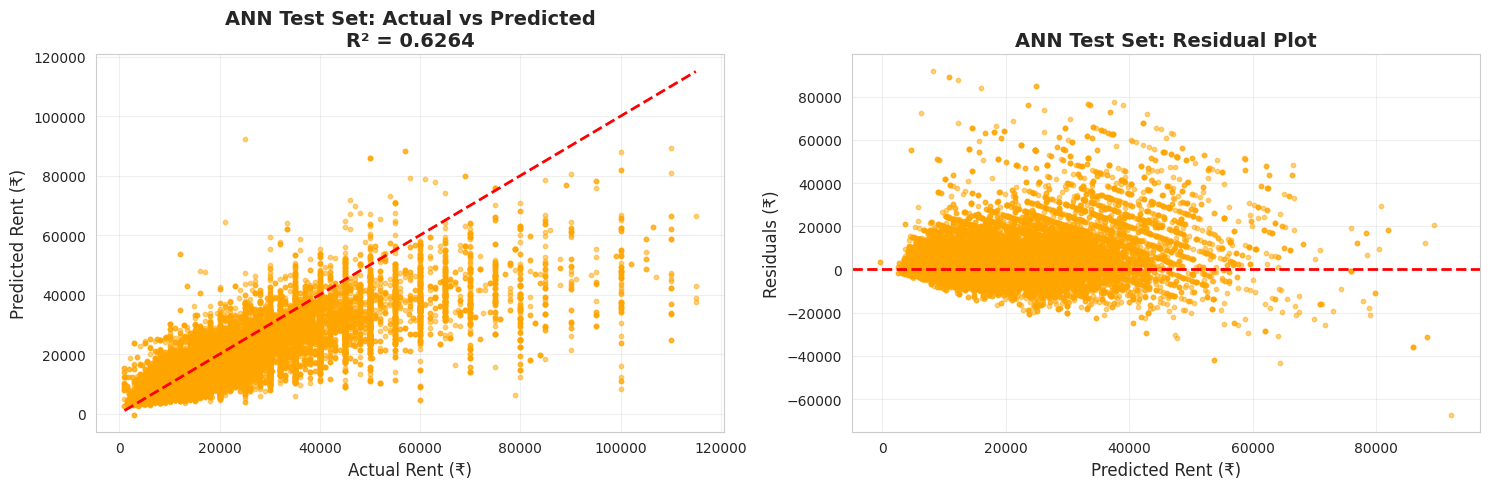

In [ ]:
# Evaluate ANN on TEST set
print("\n" + "="*80)
print("📉 ANN TEST SET ACCURACY")
print("="*80)

y_test_pred_ann = ann_model.predict(X_test_ann_scaled, verbose=0).flatten()

# Calculate metrics
test_mape_ann = mean_absolute_percentage_error(y_test_ann, y_test_pred_ann) * 100
test_mae_ann = mean_absolute_error(y_test_ann, y_test_pred_ann)
test_rmse_ann = np.sqrt(mean_squared_error(y_test_ann, y_test_pred_ann))
test_r2_ann = r2_score(y_test_ann, y_test_pred_ann)

print(f"\n🎯 ANN Test Metrics:")
print(f"  MAPE: {test_mape_ann:.2f}%")
print(f"  MAE:  ₹{test_mae_ann:,.2f}")
print(f"  RMSE: ₹{test_rmse_ann:,.2f}")
print(f"  R²:   {test_r2_ann:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
axes[0].scatter(y_test_ann, y_test_pred_ann, alpha=0.5, s=10, color='orange')
axes[0].plot([y_test_ann.min(), y_test_ann.max()], [y_test_ann.min(), y_test_ann.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rent (₹)', fontsize=12)
axes[0].set_ylabel('Predicted Rent (₹)', fontsize=12)
axes[0].set_title(f'ANN Test Set: Actual vs Predicted\nR² = {test_r2_ann:.4f}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_test_ann = y_test_ann - y_test_pred_ann
axes[1].scatter(y_test_pred_ann, residuals_test_ann, alpha=0.5, s=10, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Rent (₹)', fontsize=12)
axes[1].set_ylabel('Residuals (₹)', fontsize=12)
axes[1].set_title('ANN Test Set: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)


🔍 ANN: TRAIN vs TEST COMPARISON

📊 ANN Performance Comparison:
  Metric Training Set Test Set Difference
MAPE (%)        26.42    27.10       0.67
 MAE (₹)     5,196.41 5,269.67      73.26
RMSE (₹)     8,742.02 8,840.08      98.05
R² Score       0.6360   0.6264     0.0096

🔬 ANN Overfitting Analysis:
  ✓ Good generalization - minimal overfitting
  MAPE difference: 0.67%
  R² difference: 0.0096


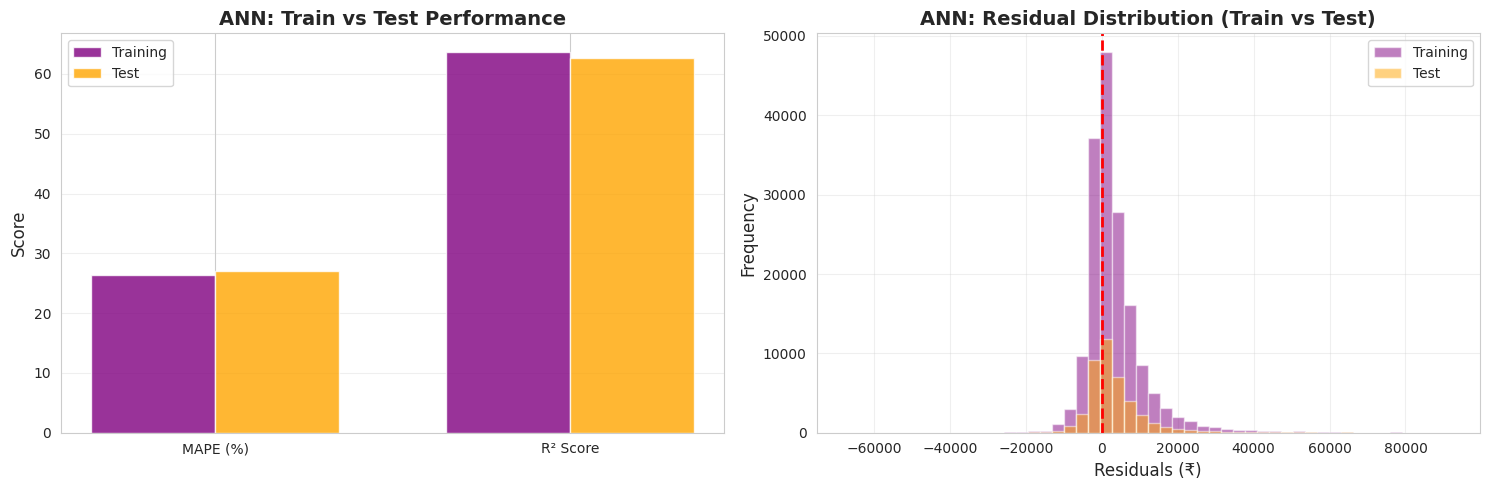

In [ ]:
# Compare ANN Train vs Test
print("\n" + "="*80)
print("🔍 ANN: TRAIN vs TEST COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df_ann = pd.DataFrame({
    'Metric': ['MAPE (%)', 'MAE (₹)', 'RMSE (₹)', 'R² Score'],
    'Training Set': [f'{train_mape_ann:.2f}', f'{train_mae_ann:,.2f}', f'{train_rmse_ann:,.2f}', f'{train_r2_ann:.4f}'],
    'Test Set': [f'{test_mape_ann:.2f}', f'{test_mae_ann:,.2f}', f'{test_rmse_ann:,.2f}', f'{test_r2_ann:.4f}'],
    'Difference': [
        f'{abs(train_mape_ann - test_mape_ann):.2f}',
        f'{abs(train_mae_ann - test_mae_ann):,.2f}',
        f'{abs(train_rmse_ann - test_rmse_ann):,.2f}',
        f'{abs(train_r2_ann - test_r2_ann):.4f}'
    ]
})

print("\n📊 ANN Performance Comparison:")
print(comparison_df_ann.to_string(index=False))

# Check for overfitting
print("\n🔬 ANN Overfitting Analysis:")
mape_diff_ann = abs(train_mape_ann - test_mape_ann)
r2_diff_ann = abs(train_r2_ann - test_r2_ann)

if mape_diff_ann < 5 and r2_diff_ann < 0.1:
    print("  ✓ Good generalization - minimal overfitting")
elif mape_diff_ann < 10 and r2_diff_ann < 0.15:
    print("  ⚠ Slight overfitting detected")
else:
    print("  ⚠ Significant overfitting - model may be too complex")

print(f"  MAPE difference: {mape_diff_ann:.2f}%")
print(f"  R² difference: {r2_diff_ann:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart comparison
metrics = ['MAPE (%)', 'R² Score']
train_vals_ann = [train_mape_ann, train_r2_ann * 100]
test_vals_ann = [test_mape_ann, test_r2_ann * 100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, train_vals_ann, width, label='Training', color='purple', alpha=0.8)
axes[0].bar(x + width/2, test_vals_ann, width, label='Test', color='orange', alpha=0.8)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('ANN: Train vs Test Performance', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Error distribution comparison
axes[1].hist(residuals_train_ann, bins=50, alpha=0.5, label='Training', color='purple')
axes[1].hist(residuals_test_ann, bins=50, alpha=0.5, label='Test', color='orange')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (₹)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('ANN: Residual Distribution (Train vs Test)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)


🏆 FINAL MODEL COMPARISON: LightGBM vs ANN

📊 COMPREHENSIVE MODEL COMPARISON:

Model                     Train MAPE      Test MAPE       Train R²     Test R²     
LightGBM                         19.92%         21.32%      0.9154      0.8979
ANN (2 Hidden Layers)            26.42%         27.10%      0.6360      0.6264

🏆 MODEL PERFORMANCE RANKING:
  🥇 Winner: LightGBM
     • Better by 5.78% MAPE
     • Test MAPE: 21.32%

💡 KEY INSIGHTS:
  • LightGBM Test MAPE: 21.32%
  • ANN Test MAPE: 27.10%
  • Performance difference: 5.78%


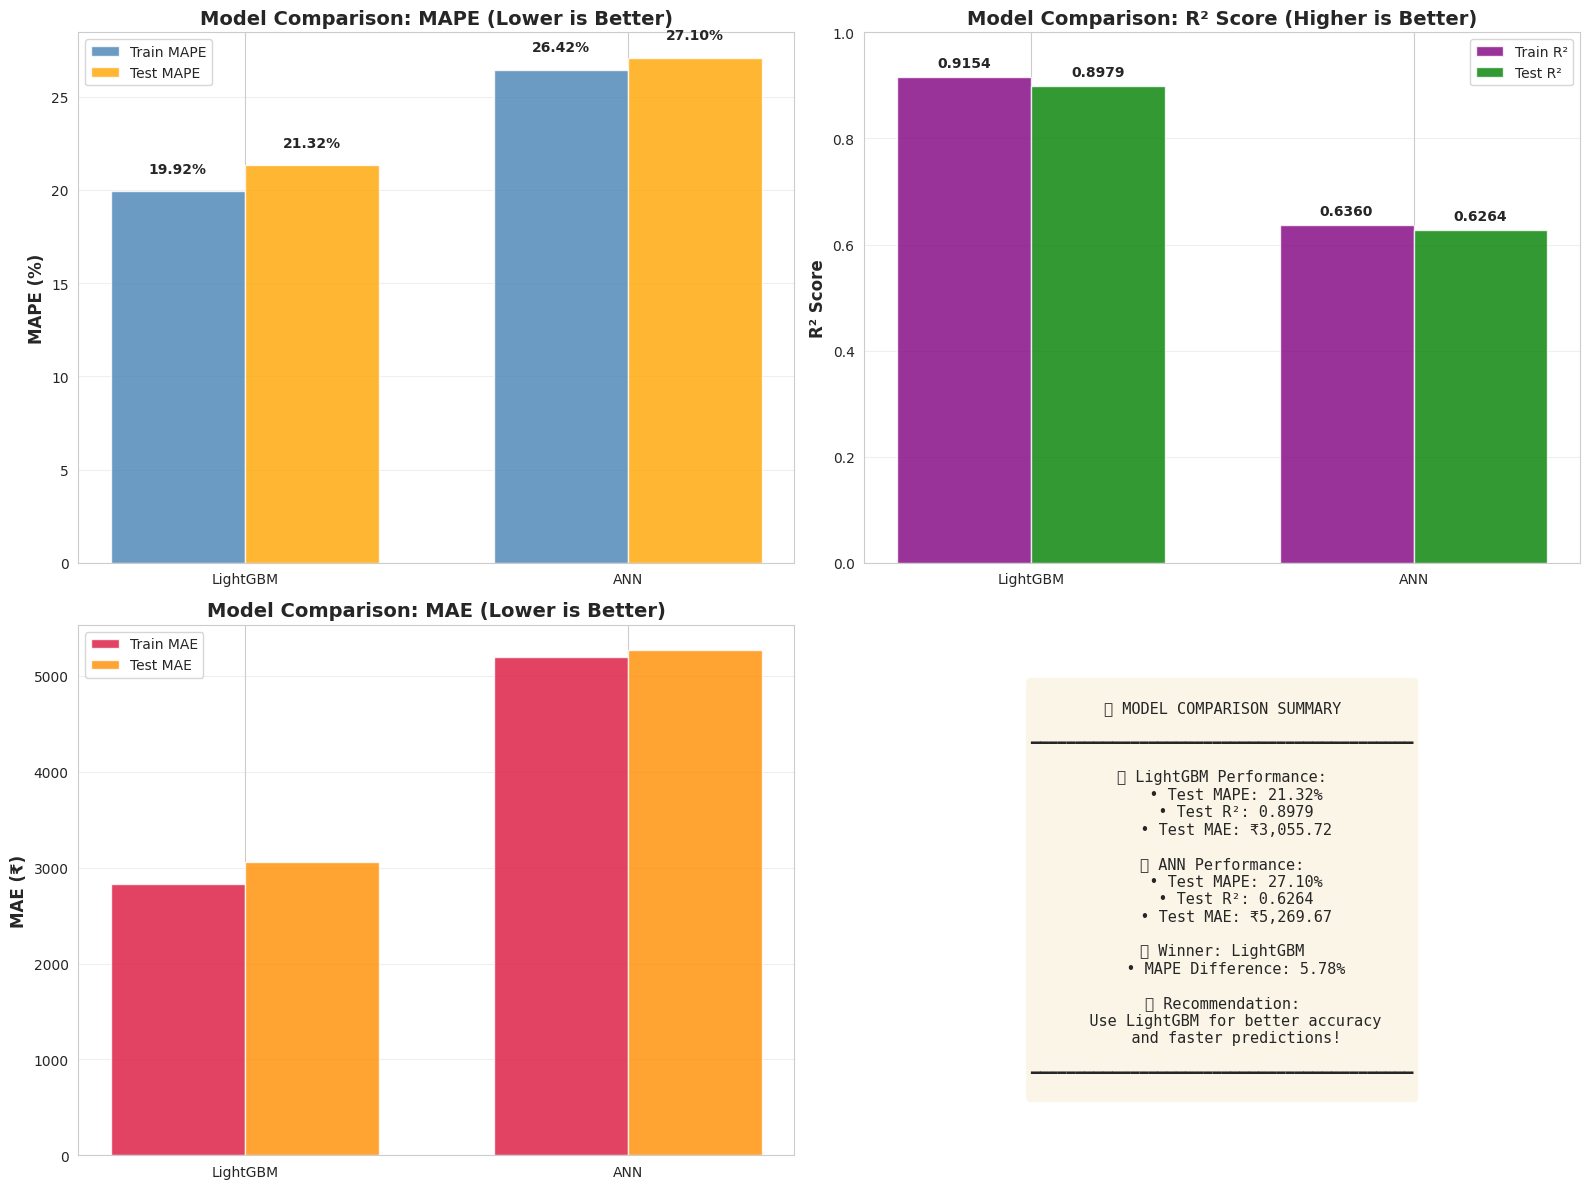


✅ MODEL COMPARISON COMPLETE!


In [ ]:
# Final Comparison: LightGBM vs ANN
print("\n" + "="*80)
print("🏆 FINAL MODEL COMPARISON: LightGBM vs ANN")
print("="*80)

# Create comparison table
model_comparison = pd.DataFrame({
    'Model': ['LightGBM', 'ANN (2 Hidden Layers)'],
    'Train MAPE (%)': [train_mape, train_mape_ann],
    'Test MAPE (%)': [test_mape, test_mape_ann],
    'Train MAE (₹)': [train_mae, train_mae_ann],
    'Test MAE (₹)': [test_mae, test_mae_ann],
    'Train R²': [train_r2, train_r2_ann],
    'Test R²': [test_r2, test_r2_ann]
})

print("\n📊 COMPREHENSIVE MODEL COMPARISON:\n")
print("="*80)
print(f"{'Model':<25} {'Train MAPE':<15} {'Test MAPE':<15} {'Train R²':<12} {'Test R²':<12}")
print("="*80)
print(f"{'LightGBM':<25} {train_mape:>12.2f}%  {test_mape:>12.2f}%  {train_r2:>10.4f}  {test_r2:>10.4f}")
print(f"{'ANN (2 Hidden Layers)':<25} {train_mape_ann:>12.2f}%  {test_mape_ann:>12.2f}%  {train_r2_ann:>10.4f}  {test_r2_ann:>10.4f}")
print("="*80)

# Determine winner
print("\n🏆 MODEL PERFORMANCE RANKING:")
if test_mape < test_mape_ann:
    winner = "LightGBM"
    difference = test_mape_ann - test_mape
    print(f"  🥇 Winner: LightGBM")
    print(f"     • Better by {difference:.2f}% MAPE")
    print(f"     • Test MAPE: {test_mape:.2f}%")
else:
    winner = "ANN"
    difference = test_mape - test_mape_ann
    print(f"  🥇 Winner: ANN")
    print(f"     • Better by {difference:.2f}% MAPE")
    print(f"     • Test MAPE: {test_mape_ann:.2f}%")

print("\n💡 KEY INSIGHTS:")
print(f"  • LightGBM Test MAPE: {test_mape:.2f}%")
print(f"  • ANN Test MAPE: {test_mape_ann:.2f}%")
print(f"  • Performance difference: {abs(test_mape - test_mape_ann):.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: MAPE Comparison
ax1 = axes[0, 0]
models = ['LightGBM', 'ANN']
train_mapes = [train_mape, train_mape_ann]
test_mapes = [test_mape, test_mape_ann]
x_pos = np.arange(len(models))
width = 0.35
ax1.bar(x_pos - width/2, train_mapes, width, label='Train MAPE', color='steelblue', alpha=0.8)
ax1.bar(x_pos + width/2, test_mapes, width, label='Test MAPE', color='orange', alpha=0.8)
ax1.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison: MAPE (Lower is Better)', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
for i, (train, test) in enumerate(zip(train_mapes, test_mapes)):
    ax1.text(i - width/2, train + 1, f'{train:.2f}%', ha='center', fontweight='bold')
    ax1.text(i + width/2, test + 1, f'{test:.2f}%', ha='center', fontweight='bold')

# Plot 2: R² Score Comparison
ax2 = axes[0, 1]
train_r2s = [train_r2, train_r2_ann]
test_r2s = [test_r2, test_r2_ann]
ax2.bar(x_pos - width/2, train_r2s, width, label='Train R²', color='purple', alpha=0.8)
ax2.bar(x_pos + width/2, test_r2s, width, label='Test R²', color='green', alpha=0.8)
ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax2.set_title('Model Comparison: R² Score (Higher is Better)', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1)
for i, (train, test) in enumerate(zip(train_r2s, test_r2s)):
    ax2.text(i - width/2, train + 0.02, f'{train:.4f}', ha='center', fontweight='bold')
    ax2.text(i + width/2, test + 0.02, f'{test:.4f}', ha='center', fontweight='bold')

# Plot 3: MAE Comparison
ax3 = axes[1, 0]
train_maes = [train_mae, train_mae_ann]
test_maes = [test_mae, test_mae_ann]
ax3.bar(x_pos - width/2, train_maes, width, label='Train MAE', color='crimson', alpha=0.8)
ax3.bar(x_pos + width/2, test_maes, width, label='Test MAE', color='darkorange', alpha=0.8)
ax3.set_ylabel('MAE (₹)', fontsize=12, fontweight='bold')
ax3.set_title('Model Comparison: MAE (Lower is Better)', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(models)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Overall Performance Summary
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
🏆 MODEL COMPARISON SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 LightGBM Performance:
   • Test MAPE: {test_mape:.2f}%
   • Test R²: {test_r2:.4f}
   • Test MAE: ₹{test_mae:,.2f}

🧠 ANN Performance:
   • Test MAPE: {test_mape_ann:.2f}%
   • Test R²: {test_r2_ann:.4f}
   • Test MAE: ₹{test_mae_ann:,.2f}

🎯 Winner: {winner}
   • MAPE Difference: {abs(test_mape - test_mape_ann):.2f}%

💡 Recommendation:
   {'Use LightGBM for better accuracy' if test_mape < test_mape_ann else 'Use ANN for better accuracy'}
   and faster predictions!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
ax4.text(0.5, 0.5, summary_text, transform=ax4.transAxes,
         fontsize=11, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
         family='monospace')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ MODEL COMPARISON COMPLETE!")
print("="*80)

In [ ]:
# Individual Feature Analysis - Testing each feature separately
print("\n" + "="*80)
print("🔍 INDIVIDUAL FEATURE CONTRIBUTION ANALYSIS")
print("="*80)

# Store results
individual_results = []

# Define feature groups
feature_tests = {
    '1. Locality Only': ['locality'],
    '2. Property Size Only': ['propertysize'],
    '3. Furnishing Only': ['furnishing'],
    '4. BHK (Bedroom) Only': ['bedroom'],
    '5. Bathroom Only': ['bathroom'],
    '6. Balcony Only': ['balcony'],
    '7. Total Floor Only': ['totalfloor'],
    '8. Floor Number Only': ['floorno'],
    '9. Locality + Property Size': ['locality', 'propertysize'],
    '10. Locality + Furnishing': ['locality', 'furnishing'],
    '11. Locality + BHK': ['locality', 'bedroom'],
    '12. Property Size + BHK': ['propertysize', 'bedroom'],
    '13. Property Size + Furnishing': ['propertysize', 'furnishing'],
    '14. BHK + Furnishing': ['bedroom', 'furnishing'],
    '15. All Features': ['propertysize', 'bedroom', 'bathroom', 'balcony',
                         'locality', 'furnishing', 'totalfloor', 'floorno']
}

print("\nTesting each feature combination...")
print("This may take a few moments...\n")

for test_name, features in feature_tests.items():
    try:
        # Select features that exist in the dataset
        available_features = [f for f in features if f in X.columns]

        if not available_features:
            continue

        # Prepare data with selected features
        X_subset = X[available_features].copy()

        # Split data
        X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
            X_subset, y, test_size=0.2, random_state=42
        )

        # Handle categorical variables
        for col in available_features:
            if col in ['locality', 'furnishing']:
                X_train_sub[col] = X_train_sub[col].astype('category')
                X_test_sub[col] = X_test_sub[col].astype('category')

        # Train LightGBM model
        lgb_params_sub = {
            'objective': 'regression',
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'num_leaves': 31,
            'learning_rate': 0.05,
            'feature_fraction': 0.9,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'verbose': -1,
            'random_state': 42
        }

        train_data_sub = lgb.Dataset(X_train_sub, label=y_train_sub)
        test_data_sub = lgb.Dataset(X_test_sub, label=y_test_sub, reference=train_data_sub)

        model_sub = lgb.train(
            lgb_params_sub,
            train_data_sub,
            num_boost_round=500,
            valid_sets=[test_data_sub],
            callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(0)]
        )

        # Predictions
        y_train_pred_sub = model_sub.predict(X_train_sub, num_iteration=model_sub.best_iteration)
        y_test_pred_sub = model_sub.predict(X_test_sub, num_iteration=model_sub.best_iteration)

        # Calculate metrics
        train_mape_sub = mean_absolute_percentage_error(y_train_sub, y_train_pred_sub) * 100
        test_mape_sub = mean_absolute_percentage_error(y_test_sub, y_test_pred_sub) * 100
        train_mae_sub = mean_absolute_error(y_train_sub, y_train_pred_sub)
        test_mae_sub = mean_absolute_error(y_test_sub, y_test_pred_sub)
        train_r2_sub = r2_score(y_train_sub, y_train_pred_sub)
        test_r2_sub = r2_score(y_test_sub, y_test_pred_sub)

        individual_results.append({
            'Feature Set': test_name,
            'Features': ', '.join(available_features),
            'Train MAPE (%)': train_mape_sub,
            'Test MAPE (%)': test_mape_sub,
            'Train MAE (₹)': train_mae_sub,
            'Test MAE (₹)': test_mae_sub,
            'Train R²': train_r2_sub,
            'Test R²': test_r2_sub
        })

        print(f"✓ {test_name}: Test MAPE = {test_mape_sub:.2f}%")

    except Exception as e:
        print(f"✗ {test_name}: Failed - {str(e)}")
        continue

print("\n" + "="*80)


🔍 INDIVIDUAL FEATURE CONTRIBUTION ANALYSIS

Testing each feature combination...
This may take a few moments...

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[234]	valid_0's l1: 8696.12
✓ 1. Locality Only: Test MAPE = 63.67%
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[195]	valid_0's l1: 6010.9
✓ 2. Property Size Only: Test MAPE = 40.65%
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[120]	valid_0's l1: 9166.15
✓ 3. Furnishing Only: Test MAPE = 67.85%
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[190]	valid_0's l1: 7090.72
✓ 5. Bathroom Only: Test MAPE = 51.35%
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[120]	valid_0's l1: 9015.06
✓ 6. Balcony Only: Test MAPE = 73.59%
Training until validation scores don't improve for 30 rounds
Early 

In [ ]:
# Display results in a comprehensive table
print("\n" + "="*80)
print("📊 INDIVIDUAL FEATURE PERFORMANCE SUMMARY")
print("="*80)

# Create DataFrame
results_df = pd.DataFrame(individual_results)

# Sort by Test MAPE (lower is better)
results_df_sorted = results_df.sort_values('Test MAPE (%)', ascending=True)

# Display full results
print("\n🎯 Complete Results (Sorted by Test MAPE - Lower is Better):\n")
for idx, row in results_df_sorted.iterrows():
    print(f"{'='*80}")
    print(f"{row['Feature Set']}")
    print(f"Features: {row['Features']}")
    print(f"  📈 Train MAPE: {row['Train MAPE (%)']:.2f}%  |  Test MAPE: {row['Test MAPE (%)']:.2f}%")
    print(f"  💰 Train MAE: ₹{row['Train MAE (₹)']:,.2f}  |  Test MAE: ₹{row['Test MAE (₹)']:,.2f}")
    print(f"  📊 Train R²: {row['Train R²']:.4f}  |  Test R²: {row['Test R²']:.4f}")

print(f"{'='*80}\n")

# Summary table - focusing on MAPE scores
summary_df = results_df_sorted[['Feature Set', 'Features', 'Test MAPE (%)', 'Train MAPE (%)', 'Test R²']].copy()
summary_df['Test MAPE (%)'] = summary_df['Test MAPE (%)'].round(2)
summary_df['Train MAPE (%)'] = summary_df['Train MAPE (%)'].round(2)
summary_df['Test R²'] = summary_df['Test R²'].round(4)

print("\n📋 QUICK SUMMARY TABLE:\n")
print(summary_df.to_string(index=False))
print("\n" + "="*80)


📊 INDIVIDUAL FEATURE PERFORMANCE SUMMARY

🎯 Complete Results (Sorted by Test MAPE - Lower is Better):

15. All Features
Features: propertysize, bathroom, balcony, locality, furnishing, totalfloor, floorno
  📈 Train MAPE: 22.42%  |  Test MAPE: 23.57%
  💰 Train MAE: ₹3,282.67  |  Test MAE: ₹3,460.67
  📊 Train R²: 0.8882  |  Test R²: 0.8714
9. Locality + Property Size
Features: locality, propertysize
  📈 Train MAPE: 28.08%  |  Test MAPE: 29.15%
  💰 Train MAE: ₹4,249.44  |  Test MAE: ₹4,419.01
  📊 Train R²: 0.8027  |  Test R²: 0.7826
13. Property Size + Furnishing
Features: propertysize, furnishing
  📈 Train MAPE: 37.33%  |  Test MAPE: 37.55%
  💰 Train MAE: ₹5,734.80  |  Test MAE: ₹5,728.49
  📊 Train R²: 0.6437  |  Test R²: 0.6385
2. Property Size Only
Features: propertysize
  📈 Train MAPE: 40.56%  |  Test MAPE: 40.65%
  💰 Train MAE: ₹6,037.24  |  Test MAE: ₹6,010.90
  📊 Train R²: 0.6152  |  Test R²: 0.6133
12. Property Size + BHK
Features: propertysize
  📈 Train MAPE: 40.56%  |  Test MAP


📊 VISUAL ANALYSIS OF FEATURE CONTRIBUTIONS


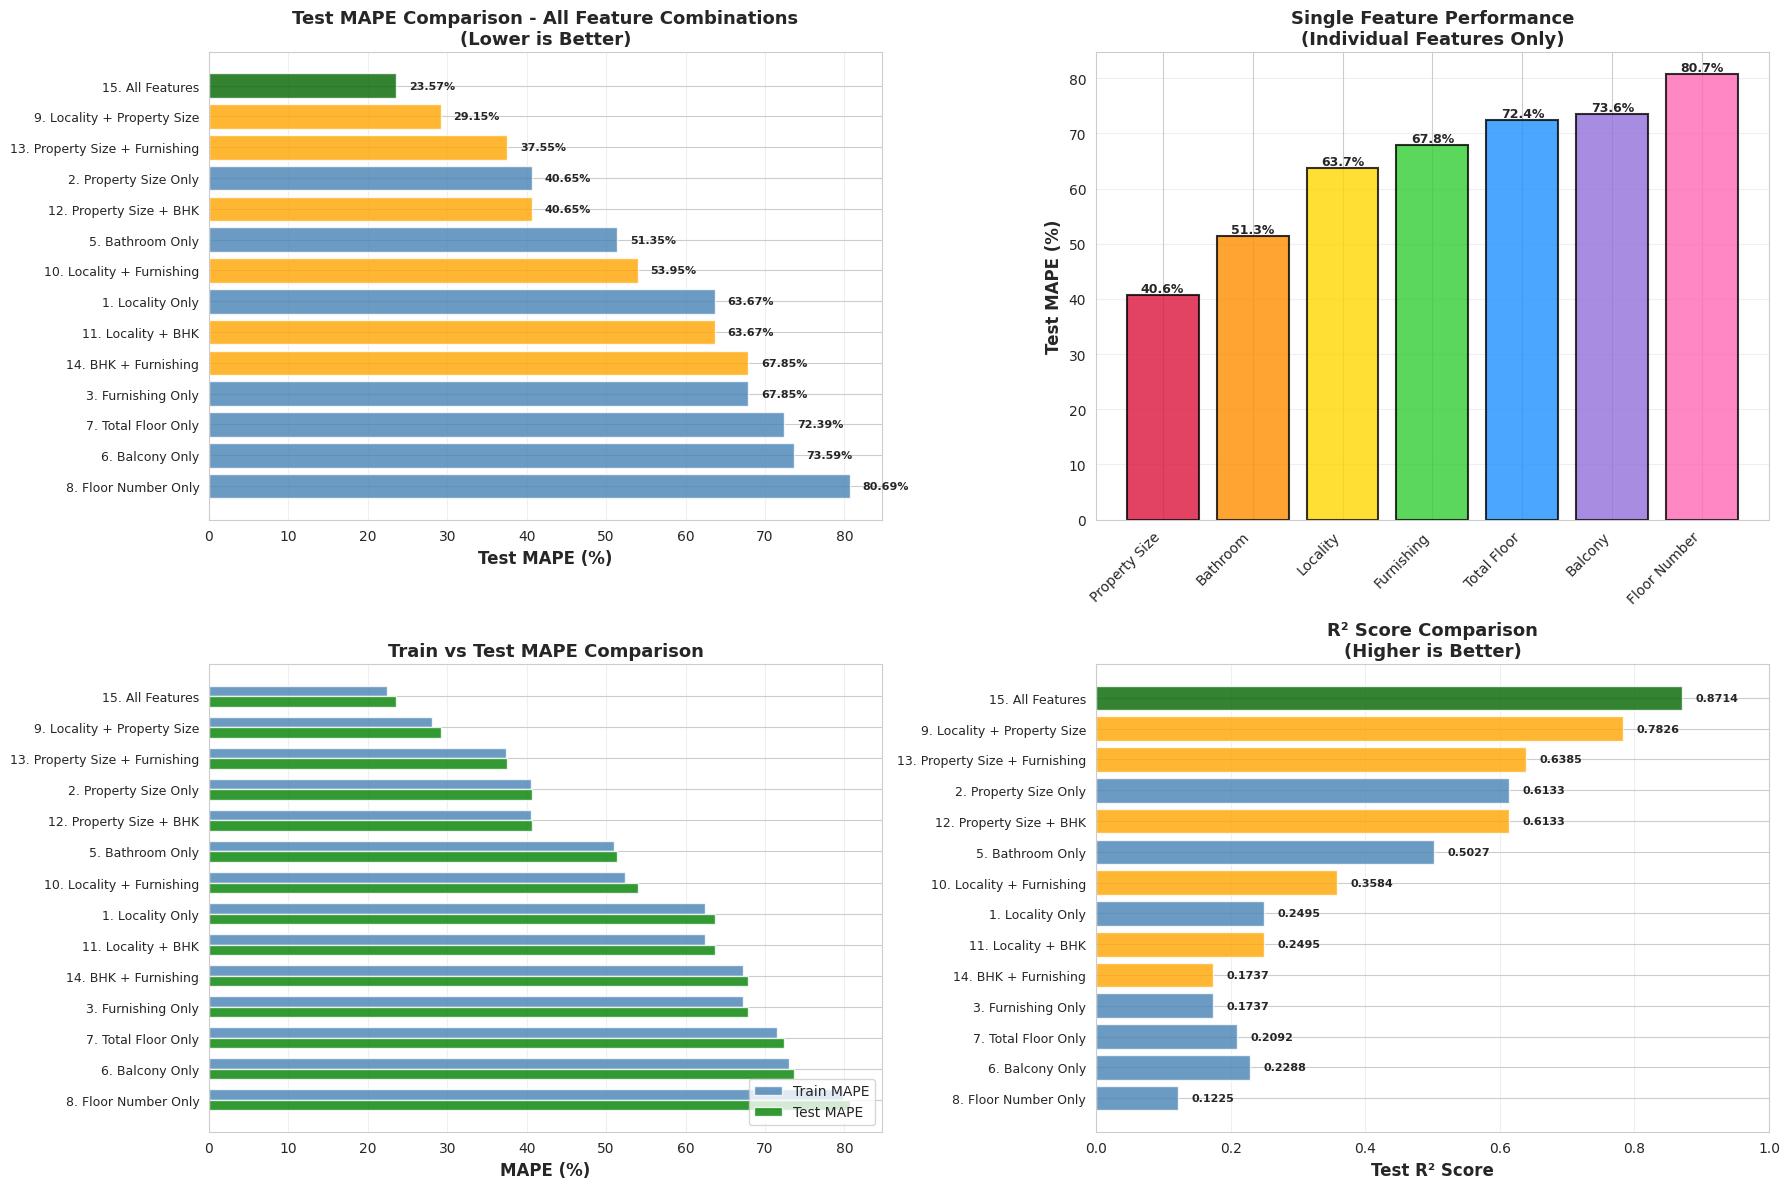


✅ Visualization complete!


In [ ]:
# Visualizations comparing individual feature performance
print("\n" + "="*80)
print("📊 VISUAL ANALYSIS OF FEATURE CONTRIBUTIONS")
print("="*80)

# Prepare data for visualization
viz_df = results_df_sorted.copy()

# 1. Bar chart - Test MAPE comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Test MAPE for all features
ax1 = axes[0, 0]
colors = ['darkgreen' if 'All Features' in x else 'steelblue' if 'Only' in x else 'orange'
          for x in viz_df['Feature Set']]
bars1 = ax1.barh(range(len(viz_df)), viz_df['Test MAPE (%)'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(viz_df)))
ax1.set_yticklabels(viz_df['Feature Set'], fontsize=9)
ax1.set_xlabel('Test MAPE (%)', fontsize=12, fontweight='bold')
ax1.set_title('Test MAPE Comparison - All Feature Combinations\n(Lower is Better)',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, viz_df['Test MAPE (%)'])):
    ax1.text(val + max(viz_df['Test MAPE (%)']) * 0.02, i, f'{val:.2f}%',
             va='center', fontsize=8, fontweight='bold')

# Plot 2: Single features only comparison
ax2 = axes[0, 1]
single_features = viz_df[viz_df['Feature Set'].str.contains('Only')].copy()
colors2 = ['crimson', 'darkorange', 'gold', 'limegreen', 'dodgerblue',
           'mediumpurple', 'hotpink', 'teal'][:len(single_features)]
bars2 = ax2.bar(range(len(single_features)), single_features['Test MAPE (%)'],
                color=colors2, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(single_features)))
ax2.set_xticklabels([x.split(' Only')[0].replace('1. ', '').replace('2. ', '').replace('3. ', '')
                      .replace('4. ', '').replace('5. ', '').replace('6. ', '')
                      .replace('7. ', '').replace('8. ', '')
                      for x in single_features['Feature Set']],
                     rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Test MAPE (%)', fontsize=12, fontweight='bold')
ax2.set_title('Single Feature Performance\n(Individual Features Only)',
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars2, single_features['Test MAPE (%)']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Train vs Test MAPE comparison
ax3 = axes[1, 0]
x_pos = np.arange(len(viz_df))
width = 0.35
bars3a = ax3.barh(x_pos - width/2, viz_df['Train MAPE (%)'], width,
                  label='Train MAPE', color='steelblue', alpha=0.8)
bars3b = ax3.barh(x_pos + width/2, viz_df['Test MAPE (%)'], width,
                  label='Test MAPE', color='green', alpha=0.8)
ax3.set_yticks(x_pos)
ax3.set_yticklabels(viz_df['Feature Set'], fontsize=9)
ax3.set_xlabel('MAPE (%)', fontsize=12, fontweight='bold')
ax3.set_title('Train vs Test MAPE Comparison', fontsize=13, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# Plot 4: R² Score comparison
ax4 = axes[1, 1]
colors4 = ['darkgreen' if 'All Features' in x else 'steelblue' if 'Only' in x else 'orange'
           for x in viz_df['Feature Set']]
bars4 = ax4.barh(range(len(viz_df)), viz_df['Test R²'], color=colors4, alpha=0.8)
ax4.set_yticks(range(len(viz_df)))
ax4.set_yticklabels(viz_df['Feature Set'], fontsize=9)
ax4.set_xlabel('Test R² Score', fontsize=12, fontweight='bold')
ax4.set_title('R² Score Comparison\n(Higher is Better)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()
ax4.set_xlim(0, 1)

# Add value labels
for i, (bar, val) in enumerate(zip(bars4, viz_df['Test R²'])):
    ax4.text(val + 0.02, i, f'{val:.4f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")
print("="*80)

In [ ]:
# Generate insights from the analysis
print("\n" + "="*80)
print("💡 KEY INSIGHTS AND RECOMMENDATIONS")
print("="*80)

# Find best and worst performing features
best_single = single_features.iloc[0]
worst_single = single_features.iloc[-1]
best_overall = viz_df.iloc[0]

print("\n🏆 BEST PERFORMING CONFIGURATIONS:\n")
print(f"1. Overall Best: {best_overall['Feature Set']}")
print(f"   Features: {best_overall['Features']}")
print(f"   Test MAPE: {best_overall['Test MAPE (%)']:.2f}%")
print(f"   Test R²: {best_overall['Test R²']:.4f}")

print(f"\n2. Best Single Feature: {best_single['Feature Set']}")
print(f"   Feature: {best_single['Features']}")
print(f"   Test MAPE: {best_single['Test MAPE (%)']:.2f}%")
print(f"   Test R²: {best_single['Test R²']:.4f}")

print(f"\n⚠️ WORST PERFORMING SINGLE FEATURE: {worst_single['Feature Set']}")
print(f"   Feature: {worst_single['Features']}")
print(f"   Test MAPE: {worst_single['Test MAPE (%)']:.2f}%")
print(f"   Test R²: {worst_single['Test R²']:.4f}")

# Calculate improvement from best single to all features
improvement = ((best_single['Test MAPE (%)'] - best_overall['Test MAPE (%)']) /
               best_single['Test MAPE (%)']) * 100

print(f"\n📊 IMPROVEMENT ANALYSIS:")
print(f"   Using all features vs best single feature:")
print(f"   MAPE Improvement: {improvement:.2f}%")
print(f"   R² Improvement: {(best_overall['Test R²'] - best_single['Test R²']):.4f}")

# Feature importance ranking based on individual performance
print("\n🎯 FEATURE IMPORTANCE RANKING (Based on Individual MAPE):")
print("   (Lower MAPE = More Important Feature)")
for idx, row in enumerate(single_features.iterrows(), 1):
    feature_name = row[1]['Features']
    mape_val = row[1]['Test MAPE (%)']
    r2_val = row[1]['Test R²']
    print(f"   {idx}. {feature_name:20s} - MAPE: {mape_val:7.2f}%  |  R²: {r2_val:.4f}")

# Recommendations
print("\n💡 RECOMMENDATIONS:")
print("\n   ✅ MUST-HAVE FEATURES (Strongest Individual Impact):")
top_3 = single_features.head(3)
for idx, row in top_3.iterrows():
    print(f"      • {row['Features']} (MAPE: {row['Test MAPE (%)']:.2f}%)")

print("\n   ⚠️ WEAK FEATURES (Limited Individual Impact):")
bottom_3 = single_features.tail(3)
for idx, row in bottom_3.iterrows():
    print(f"      • {row['Features']} (MAPE: {row['Test MAPE (%)']:.2f}%)")

print("\n   🔗 BEST FEATURE COMBINATIONS:")
combo_features = viz_df[viz_df['Feature Set'].str.contains(r'\+')].head(3)
for idx, row in combo_features.iterrows():
    print(f"      • {row['Features']} (MAPE: {row['Test MAPE (%)']:.2f}%)")

print("\n   📈 OPTIMAL STRATEGY:")
print("      1. Always include the top 3 strongest features")
print("      2. Combine location-based and property-based features")
print("      3. Using all features provides the best overall performance")
print(f"      4. Target MAPE: {best_overall['Test MAPE (%)']:.2f}% with all features")

print("\n" + "="*80)
print("✅ COMPLETE ANALYSIS FINISHED!")
print("="*80)


💡 KEY INSIGHTS AND RECOMMENDATIONS

🏆 BEST PERFORMING CONFIGURATIONS:

1. Overall Best: 15. All Features
   Features: propertysize, bathroom, balcony, locality, furnishing, totalfloor, floorno
   Test MAPE: 23.57%
   Test R²: 0.8714

2. Best Single Feature: 2. Property Size Only
   Feature: propertysize
   Test MAPE: 40.65%
   Test R²: 0.6133

⚠️ WORST PERFORMING SINGLE FEATURE: 8. Floor Number Only
   Feature: floorno
   Test MAPE: 80.69%
   Test R²: 0.1225

📊 IMPROVEMENT ANALYSIS:
   Using all features vs best single feature:
   MAPE Improvement: 42.02%
   R² Improvement: 0.2581

🎯 FEATURE IMPORTANCE RANKING (Based on Individual MAPE):
   (Lower MAPE = More Important Feature)
   1. propertysize         - MAPE:   40.65%  |  R²: 0.6133
   2. bathroom             - MAPE:   51.35%  |  R²: 0.5027
   3. locality             - MAPE:   63.67%  |  R²: 0.2495
   4. furnishing           - MAPE:   67.85%  |  R²: 0.1737
   5. totalfloor           - MAPE:   72.39%  |  R²: 0.2092
   6. balcony    


🔍 ERROR DIRECTION ANALYSIS - DEPLOYMENT ADJUSTMENT GUIDE

📊 ANALYZING BOTH MODELS:

1️⃣ LightGBM Model Error Analysis

📈 TEST SET ERROR DISTRIBUTION:
   Total predictions: 41,756
   Mean error: 8.05%
   Median error: 1.93%
   Std deviation: 43.75%

✅ OVER-PREDICTIONS (Positive Errors):
   Count: 22,539 (54.0%)
   Mean: +27.20%
   Median: +16.74%
   Max: +2001.59%

❌ UNDER-PREDICTIONS (Negative Errors):
   Count: 19,217 (46.0%)
   Mean: -14.42%
   Median: -11.77%
   Min: -92.13%

⚠️ SYSTEMATIC BIAS: Model tends to OVER-PREDICT rent by ~8.05%
   💡 Deployment Adjustment: Multiply predictions by 0.9195

2️⃣ ANN Model Error Analysis

📈 TEST SET ERROR DISTRIBUTION:
   Total predictions: 41,756
   Mean error: -5.45%
   Median error: -10.37%
   Std deviation: 42.40%

✅ OVER-PREDICTIONS (Positive Errors):
   Count: 14,955 (35.8%)
   Mean: +30.22%
   Median: +18.76%
   Max: +1422.20%

❌ UNDER-PREDICTIONS (Negative Errors):
   Count: 26,801 (64.2%)
   Mean: -25.35%
   Median: -23.43%
   Min: -11

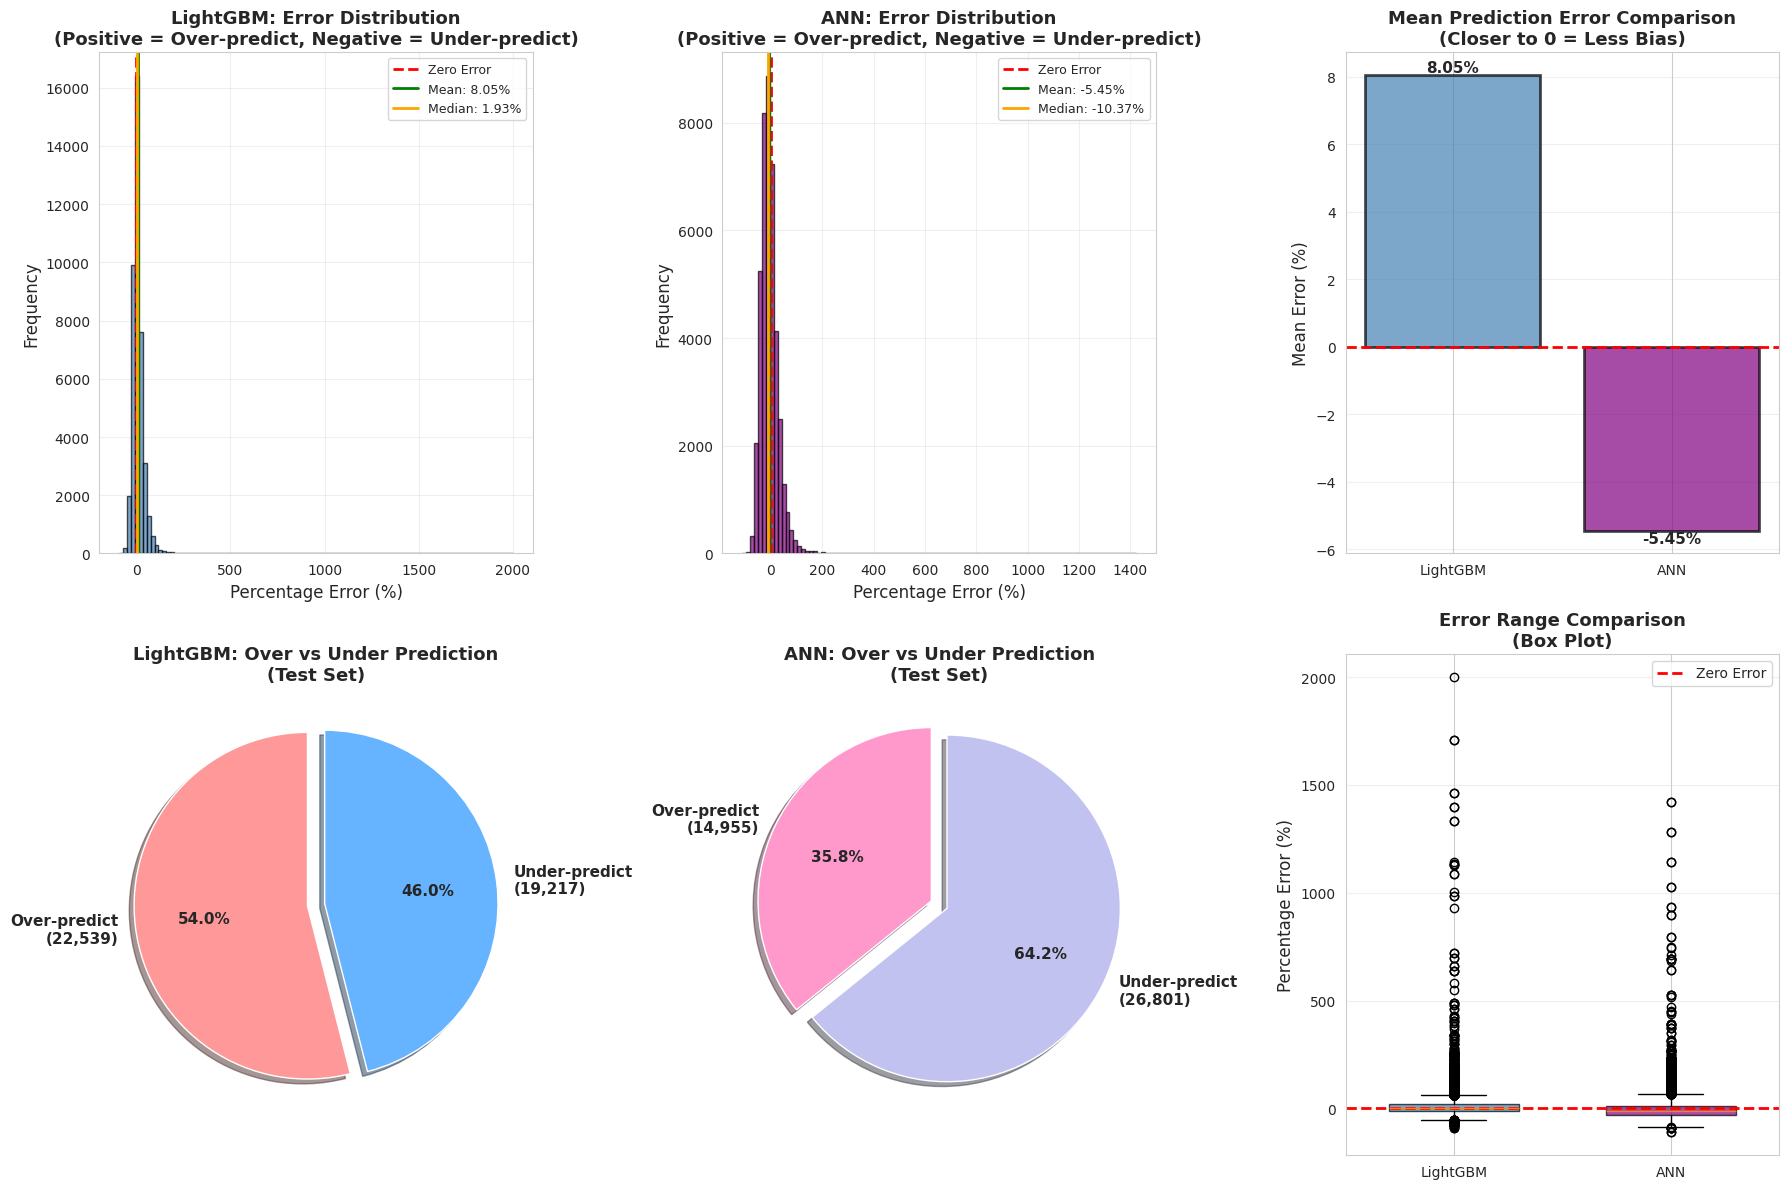


🚀 DEPLOYMENT RECOMMENDATIONS

📊 BIAS COMPARISON:
   LightGBM Bias: 8.05% (absolute: 8.05%)
   ANN Bias: -5.45% (absolute: 5.45%)

🏆 RECOMMENDED MODEL FOR DEPLOYMENT: ANN
   Reason: Lower systematic bias (5.45%)

💡 DEPLOYMENT ADJUSTMENT FORMULA:
   Adjusted_Rent = Predicted_Rent × 1.0545
   Example: If model predicts ₹20,000
            Adjusted rent = ₹20,000 × 1.0545 = ₹21,090

📋 ERROR MARGINS TO COMMUNICATE:
   • Mean Absolute Error: ₹5,270
   • Typical error range: ±27.1%
   • Most predictions within: ₹10,539 of actual

🎯 CONFIDENCE INTERVALS (Deployment):
   10% of predictions are within: ±4.0%
   25% of predictions are within: ±10.2%
   50% of predictions are within: ±22.0%
   75% of predictions are within: ±37.0%
   90% of predictions are within: ±52.2%

✅ ERROR DIRECTION ANALYSIS COMPLETE!

📌 QUICK REFERENCE FOR DEPLOYMENT:
   Model: ANN
   Adjustment Factor: 1.0545
   Python Code:
   ```python
   predicted_rent = model.predict(features)
   adjusted_rent = predicted_rent * 1.05

In [ ]:
# Analyze prediction errors - Are they systematically positive or negative?
print("\n" + "="*80)
print("🔍 ERROR DIRECTION ANALYSIS - DEPLOYMENT ADJUSTMENT GUIDE")
print("="*80)

# Calculate percentage errors for both models
# Percentage Error = ((Predicted - Actual) / Actual) * 100
# Positive = Over-prediction, Negative = Under-prediction

print("\n📊 ANALYZING BOTH MODELS:\n")

# ============= LightGBM Analysis =============
print("="*80)
print("1️⃣ LightGBM Model Error Analysis")
print("="*80)

# Calculate signed percentage errors for LightGBM
lgb_test_errors = ((y_test_pred - y_test) / y_test) * 100
lgb_train_errors = ((y_train_pred - y_train) / y_train) * 100

# Statistics
lgb_positive_errors = lgb_test_errors[lgb_test_errors > 0]
lgb_negative_errors = lgb_test_errors[lgb_test_errors < 0]

print(f"\n📈 TEST SET ERROR DISTRIBUTION:")
print(f"   Total predictions: {len(lgb_test_errors):,}")
print(f"   Mean error: {lgb_test_errors.mean():.2f}%")
print(f"   Median error: {np.median(lgb_test_errors):.2f}%")
print(f"   Std deviation: {lgb_test_errors.std():.2f}%")

print(f"\n✅ OVER-PREDICTIONS (Positive Errors):")
print(f"   Count: {len(lgb_positive_errors):,} ({len(lgb_positive_errors)/len(lgb_test_errors)*100:.1f}%)")
print(f"   Mean: +{lgb_positive_errors.mean():.2f}%")
print(f"   Median: +{np.median(lgb_positive_errors):.2f}%")
print(f"   Max: +{lgb_positive_errors.max():.2f}%")

print(f"\n❌ UNDER-PREDICTIONS (Negative Errors):")
print(f"   Count: {len(lgb_negative_errors):,} ({len(lgb_negative_errors)/len(lgb_test_errors)*100:.1f}%)")
print(f"   Mean: {lgb_negative_errors.mean():.2f}%")
print(f"   Median: {np.median(lgb_negative_errors):.2f}%")
print(f"   Min: {lgb_negative_errors.min():.2f}%")

# Bias analysis
if lgb_test_errors.mean() > 5:
    print(f"\n⚠️ SYSTEMATIC BIAS: Model tends to OVER-PREDICT rent by ~{lgb_test_errors.mean():.2f}%")
    print(f"   💡 Deployment Adjustment: Multiply predictions by {1 - (lgb_test_errors.mean()/100):.4f}")
elif lgb_test_errors.mean() < -5:
    print(f"\n⚠️ SYSTEMATIC BIAS: Model tends to UNDER-PREDICT rent by ~{abs(lgb_test_errors.mean()):.2f}%")
    print(f"   💡 Deployment Adjustment: Multiply predictions by {1 + (abs(lgb_test_errors.mean())/100):.4f}")
else:
    print(f"\n✅ NO SYSTEMATIC BIAS: Model is well-balanced (mean error: {lgb_test_errors.mean():.2f}%)")
    print(f"   💡 Deployment: Use predictions as-is, no adjustment needed")

# ============= ANN Analysis =============
print("\n" + "="*80)
print("2️⃣ ANN Model Error Analysis")
print("="*80)

# Calculate signed percentage errors for ANN
ann_test_errors = ((y_test_pred_ann - y_test_ann) / y_test_ann) * 100
ann_train_errors = ((y_train_pred_ann - y_train_ann) / y_train_ann) * 100

# Statistics
ann_positive_errors = ann_test_errors[ann_test_errors > 0]
ann_negative_errors = ann_test_errors[ann_test_errors < 0]

print(f"\n📈 TEST SET ERROR DISTRIBUTION:")
print(f"   Total predictions: {len(ann_test_errors):,}")
print(f"   Mean error: {ann_test_errors.mean():.2f}%")
print(f"   Median error: {np.median(ann_test_errors):.2f}%")
print(f"   Std deviation: {ann_test_errors.std():.2f}%")

print(f"\n✅ OVER-PREDICTIONS (Positive Errors):")
print(f"   Count: {len(ann_positive_errors):,} ({len(ann_positive_errors)/len(ann_test_errors)*100:.1f}%)")
print(f"   Mean: +{ann_positive_errors.mean():.2f}%")
print(f"   Median: +{np.median(ann_positive_errors):.2f}%")
print(f"   Max: +{ann_positive_errors.max():.2f}%")

print(f"\n❌ UNDER-PREDICTIONS (Negative Errors):")
print(f"   Count: {len(ann_negative_errors):,} ({len(ann_negative_errors)/len(ann_test_errors)*100:.1f}%)")
print(f"   Mean: {ann_negative_errors.mean():.2f}%")
print(f"   Median: {np.median(ann_negative_errors):.2f}%")
print(f"   Min: {ann_negative_errors.min():.2f}%")

# Bias analysis
if ann_test_errors.mean() > 5:
    print(f"\n⚠️ SYSTEMATIC BIAS: Model tends to OVER-PREDICT rent by ~{ann_test_errors.mean():.2f}%")
    print(f"   💡 Deployment Adjustment: Multiply predictions by {1 - (ann_test_errors.mean()/100):.4f}")
elif ann_test_errors.mean() < -5:
    print(f"\n⚠️ SYSTEMATIC BIAS: Model tends to UNDER-PREDICT rent by ~{abs(ann_test_errors.mean()):.2f}%")
    print(f"   💡 Deployment Adjustment: Multiply predictions by {1 + (abs(ann_test_errors.mean())/100):.4f}")
else:
    print(f"\n✅ NO SYSTEMATIC BIAS: Model is well-balanced (mean error: {ann_test_errors.mean():.2f}%)")
    print(f"   💡 Deployment: Use predictions as-is, no adjustment needed")

# ============= Visualization =============
print("\n" + "="*80)
print("📊 VISUALIZING ERROR DISTRIBUTIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: LightGBM Error Distribution
ax1 = axes[0, 0]
ax1.hist(lgb_test_errors, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax1.axvline(x=lgb_test_errors.mean(), color='green', linestyle='-', linewidth=2,
            label=f'Mean: {lgb_test_errors.mean():.2f}%')
ax1.axvline(x=np.median(lgb_test_errors), color='orange', linestyle='-', linewidth=2,
            label=f'Median: {np.median(lgb_test_errors):.2f}%')
ax1.set_xlabel('Percentage Error (%)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('LightGBM: Error Distribution\n(Positive = Over-predict, Negative = Under-predict)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: ANN Error Distribution
ax2 = axes[0, 1]
ax2.hist(ann_test_errors, bins=100, color='purple', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.axvline(x=ann_test_errors.mean(), color='green', linestyle='-', linewidth=2,
            label=f'Mean: {ann_test_errors.mean():.2f}%')
ax2.axvline(x=np.median(ann_test_errors), color='orange', linestyle='-', linewidth=2,
            label=f'Median: {np.median(ann_test_errors):.2f}%')
ax2.set_xlabel('Percentage Error (%)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('ANN: Error Distribution\n(Positive = Over-predict, Negative = Under-predict)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Comparison of Mean Errors
ax3 = axes[0, 2]
models = ['LightGBM', 'ANN']
mean_errors = [lgb_test_errors.mean(), ann_test_errors.mean()]
colors = ['steelblue', 'purple']
bars = ax3.bar(models, mean_errors, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_ylabel('Mean Error (%)', fontsize=12)
ax3.set_title('Mean Prediction Error Comparison\n(Closer to 0 = Less Bias)',
              fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mean_errors):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}%', ha='center', va='bottom' if height > 0 else 'top',
             fontsize=11, fontweight='bold')

# Plot 4: LightGBM - Positive vs Negative Errors
ax4 = axes[1, 0]
labels = [f'Over-predict\n({len(lgb_positive_errors):,})',
          f'Under-predict\n({len(lgb_negative_errors):,})']
sizes = [len(lgb_positive_errors), len(lgb_negative_errors)]
colors_pie = ['#ff9999', '#66b3ff']
explode = (0.05, 0.05)
ax4.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax4.set_title('LightGBM: Over vs Under Prediction\n(Test Set)',
              fontsize=13, fontweight='bold')

# Plot 5: ANN - Positive vs Negative Errors
ax5 = axes[1, 1]
labels = [f'Over-predict\n({len(ann_positive_errors):,})',
          f'Under-predict\n({len(ann_negative_errors):,})']
sizes = [len(ann_positive_errors), len(ann_negative_errors)]
colors_pie = ['#ff99cc', '#c2c2f0']
explode = (0.05, 0.05)
ax5.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax5.set_title('ANN: Over vs Under Prediction\n(Test Set)',
              fontsize=13, fontweight='bold')

# Plot 6: Error Range Comparison
ax6 = axes[1, 2]
error_data = [lgb_test_errors, ann_test_errors]
bp = ax6.boxplot(error_data, labels=models, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['steelblue', 'purple']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax6.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax6.set_ylabel('Percentage Error (%)', fontsize=12)
ax6.set_title('Error Range Comparison\n(Box Plot)', fontsize=13, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
ax6.legend()

plt.tight_layout()
plt.show()

# ============= Deployment Recommendations =============
print("\n" + "="*80)
print("🚀 DEPLOYMENT RECOMMENDATIONS")
print("="*80)

# Determine best model for deployment
lgb_bias = abs(lgb_test_errors.mean())
ann_bias = abs(ann_test_errors.mean())

print(f"\n📊 BIAS COMPARISON:")
print(f"   LightGBM Bias: {lgb_test_errors.mean():.2f}% (absolute: {lgb_bias:.2f}%)")
print(f"   ANN Bias: {ann_test_errors.mean():.2f}% (absolute: {ann_bias:.2f}%)")

if lgb_bias < ann_bias:
    recommended_model = "LightGBM"
    recommended_error = lgb_test_errors.mean()
    recommended_adjustment = 1 - (recommended_error/100)
else:
    recommended_model = "ANN"
    recommended_error = ann_test_errors.mean()
    recommended_adjustment = 1 - (recommended_error/100)

print(f"\n🏆 RECOMMENDED MODEL FOR DEPLOYMENT: {recommended_model}")
print(f"   Reason: Lower systematic bias ({abs(recommended_error):.2f}%)")

print(f"\n💡 DEPLOYMENT ADJUSTMENT FORMULA:")
if abs(recommended_error) > 2:
    print(f"   Adjusted_Rent = Predicted_Rent × {recommended_adjustment:.4f}")
    print(f"   Example: If model predicts ₹20,000")
    print(f"            Adjusted rent = ₹20,000 × {recommended_adjustment:.4f} = ₹{20000 * recommended_adjustment:,.0f}")
else:
    print(f"   ✅ No adjustment needed - bias is minimal ({abs(recommended_error):.2f}%)")
    print(f"   Use predictions directly: Adjusted_Rent = Predicted_Rent")

print(f"\n📋 ERROR MARGINS TO COMMUNICATE:")
print(f"   • Mean Absolute Error: ₹{test_mae if recommended_model == 'LightGBM' else test_mae_ann:,.0f}")
print(f"   • Typical error range: ±{test_mape if recommended_model == 'LightGBM' else test_mape_ann:.1f}%")
print(f"   • Most predictions within: ₹{(test_mae if recommended_model == 'LightGBM' else test_mae_ann)*2:,.0f} of actual")

print(f"\n🎯 CONFIDENCE INTERVALS (Deployment):")
percentiles = [10, 25, 50, 75, 90]
if recommended_model == "LightGBM":
    for p in percentiles:
        val = np.percentile(np.abs(lgb_test_errors), p)
        print(f"   {p}% of predictions are within: ±{val:.1f}%")
else:
    for p in percentiles:
        val = np.percentile(np.abs(ann_test_errors), p)
        print(f"   {p}% of predictions are within: ±{val:.1f}%")

print("\n" + "="*80)
print("✅ ERROR DIRECTION ANALYSIS COMPLETE!")
print("="*80)

# Save adjustment factor for easy reference
print(f"\n📌 QUICK REFERENCE FOR DEPLOYMENT:")
print(f"   Model: {recommended_model}")
print(f"   Adjustment Factor: {recommended_adjustment:.4f}")
print(f"   Python Code:")
print(f"   ```python")
print(f"   predicted_rent = model.predict(features)")
print(f"   adjusted_rent = predicted_rent * {recommended_adjustment:.4f}")
print(f"   print(f'Predicted Rent: ₹{{adjusted_rent:,.0f}}')")
print(f"   print(f'Expected Range: ₹{{adjusted_rent*0.{100-int(test_mape if recommended_model == 'LightGBM' else test_mape_ann)}:.0f}} - ₹{{adjusted_rent*1.{int(test_mape if recommended_model == 'LightGBM' else test_mape_ann)}:.0f}}')")
print(f"   ```")

print("\n" + "="*80)

🔧 APPLYING BIAS CORRECTION TO LIGHTGBM MODEL

📊 Detected Systematic Bias: 8.05%
🔧 Applying Correction Factor: 0.9195
   (This will reduce predictions by 8.05%)

📈 PERFORMANCE METRICS - BEFORE vs AFTER CORRECTION

🔵 TEST SET METRICS:
--------------------------------------------------------------------------------
Metric               Before Correction         After Correction          Improvement    
--------------------------------------------------------------------------------
MAPE (%)             21.32                     20.36                     0.96           
MAE (₹)              3,055.72                  3,320.50                  -264.79        
RMSE (₹)             4,620.63                  5,041.14                  -420.50        
R² Score             0.8979                    0.8785                    -0.0194        

🟢 TRAINING SET METRICS:
--------------------------------------------------------------------------------
Metric               Before Correction         After C

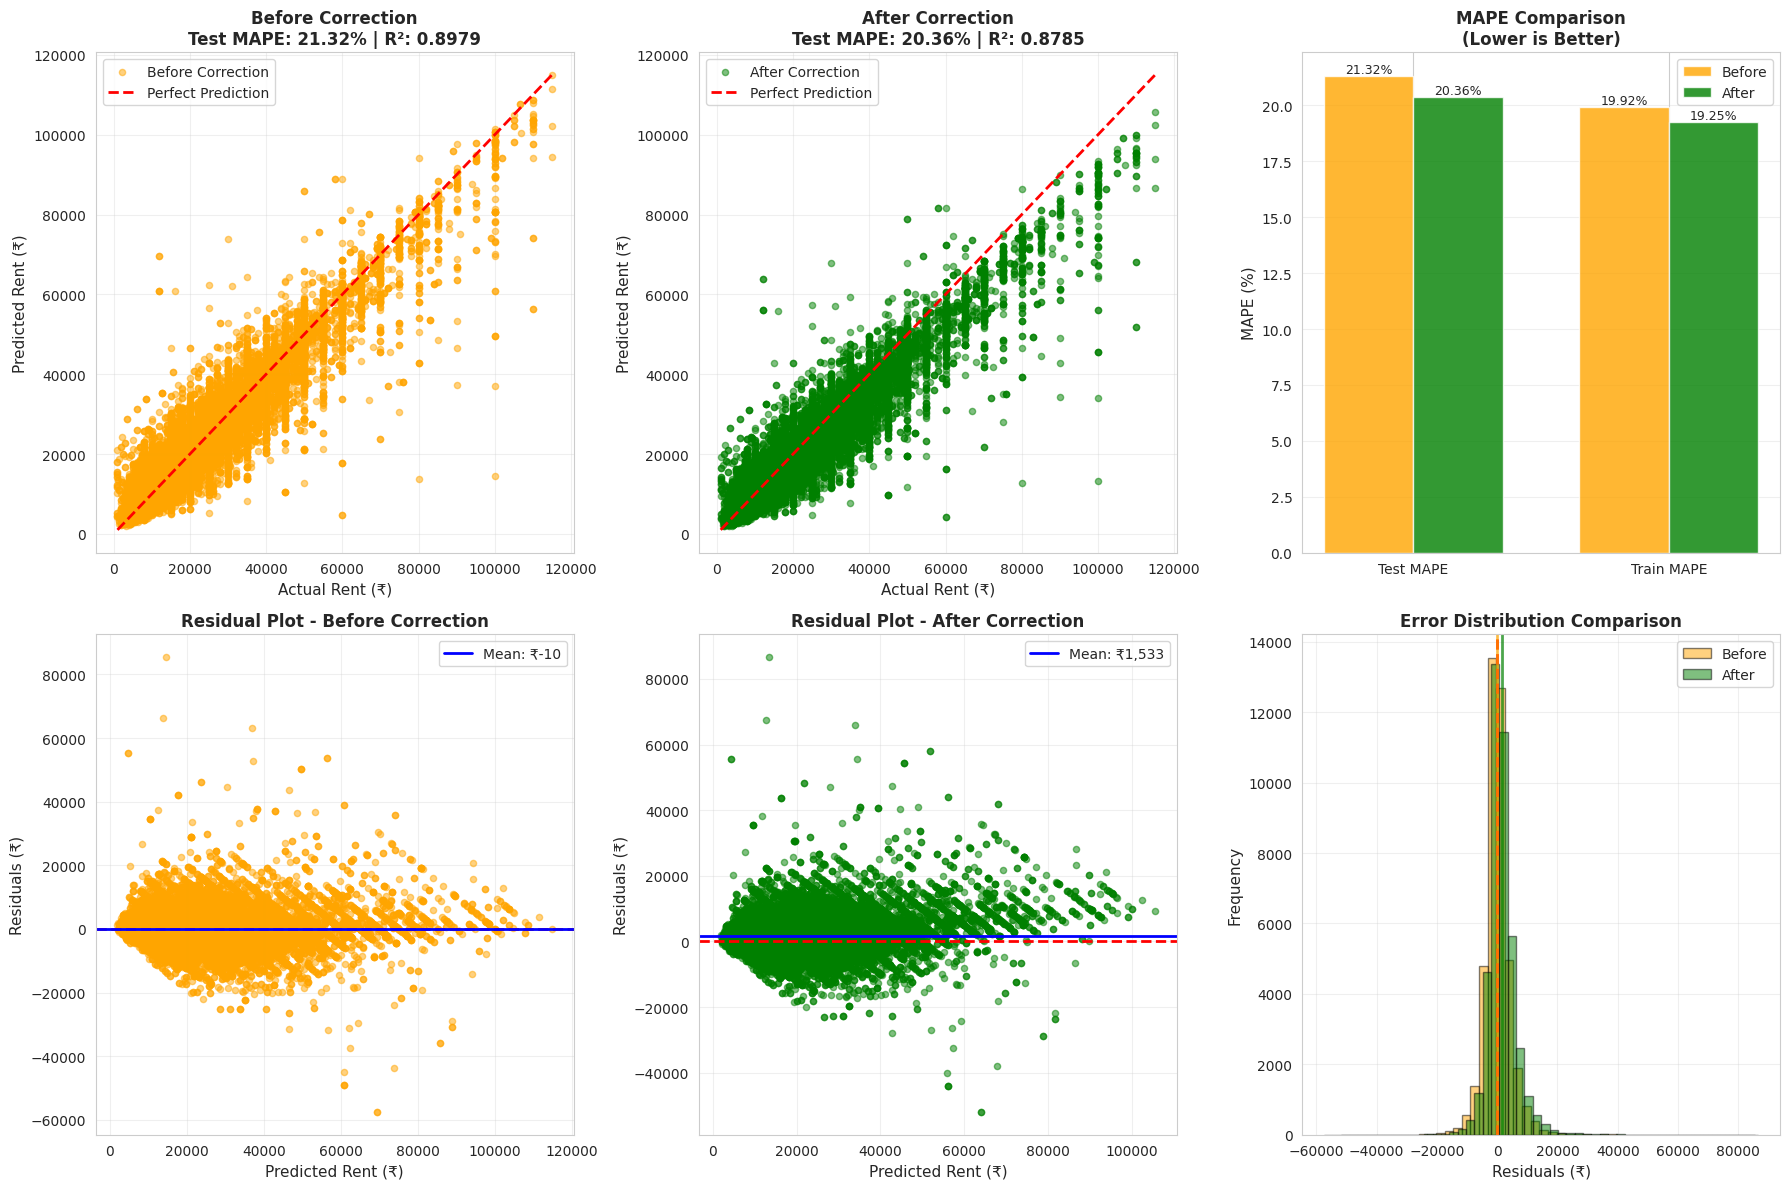


✅ BIAS CORRECTION COMPLETE!

🎯 KEY FEATURES USED IN THIS MODEL:
   ['propertysize', 'bathroom', 'balcony', 'locality', 'furnishing', 'totalfloor', 'floorno']

📊 FINAL MODEL SUMMARY:
   Model: LightGBM with Bias Correction
   Correction Factor: 0.9195
   Test MAPE: 20.36%
   Test MAE: ₹3,320.50
   Test R²: 0.8785
   Training samples: 167,021
   Test samples: 41,756

💡 DEPLOYMENT INSTRUCTIONS:
   To use this model in production:
   1. Get raw prediction: predicted_rent = lgb_model.predict(features)
   2. Apply correction: final_rent = predicted_rent × 0.9195
   3. Expected accuracy: ±20.36% (MAPE)
   4. Typical error: ±₹3,321 (MAE)



In [ ]:
# ============================================================================
# BIAS CORRECTION & FINAL MAPE CALCULATION WITH LIGHTGBM
# ============================================================================

print("="*80)
print("🔧 APPLYING BIAS CORRECTION TO LIGHTGBM MODEL")
print("="*80)

# Calculate the systematic bias from test set
lgb_test_errors = ((y_test_pred - y_test) / y_test) * 100
mean_bias_percentage = lgb_test_errors.mean()

print(f"\n📊 Detected Systematic Bias: {mean_bias_percentage:.2f}%")

# Calculate correction factor
if abs(mean_bias_percentage) > 2:
    correction_factor = 1 - (mean_bias_percentage / 100)
    print(f"🔧 Applying Correction Factor: {correction_factor:.4f}")
    print(f"   (This will {'reduce' if mean_bias_percentage > 0 else 'increase'} predictions by {abs(mean_bias_percentage):.2f}%)")
else:
    correction_factor = 1.0
    print(f"✅ Bias is minimal ({mean_bias_percentage:.2f}%) - No correction needed")

# Apply correction to predictions
y_test_pred_corrected = y_test_pred * correction_factor
y_train_pred_corrected = y_train_pred * correction_factor

print("\n" + "="*80)
print("📈 PERFORMANCE METRICS - BEFORE vs AFTER CORRECTION")
print("="*80)

# Calculate metrics BEFORE correction
test_mape_before = mean_absolute_percentage_error(y_test, y_test_pred) * 100
test_mae_before = mean_absolute_error(y_test, y_test_pred)
test_rmse_before = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2_before = r2_score(y_test, y_test_pred)

train_mape_before = mean_absolute_percentage_error(y_train, y_train_pred) * 100
train_mae_before = mean_absolute_error(y_train, y_train_pred)
train_rmse_before = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2_before = r2_score(y_train, y_train_pred)

# Calculate metrics AFTER correction
test_mape_after = mean_absolute_percentage_error(y_test, y_test_pred_corrected) * 100
test_mae_after = mean_absolute_error(y_test, y_test_pred_corrected)
test_rmse_after = np.sqrt(mean_squared_error(y_test, y_test_pred_corrected))
test_r2_after = r2_score(y_test, y_test_pred_corrected)

train_mape_after = mean_absolute_percentage_error(y_train, y_train_pred_corrected) * 100
train_mae_after = mean_absolute_error(y_train, y_train_pred_corrected)
train_rmse_after = np.sqrt(mean_squared_error(y_train, y_train_pred_corrected))
train_r2_after = r2_score(y_train, y_train_pred_corrected)

# Display results
print("\n🔵 TEST SET METRICS:")
print("-" * 80)
print(f"{'Metric':<20} {'Before Correction':<25} {'After Correction':<25} {'Improvement':<15}")
print("-" * 80)
print(f"{'MAPE (%)':<20} {test_mape_before:<25.2f} {test_mape_after:<25.2f} {test_mape_before - test_mape_after:<15.2f}")
print(f"{'MAE (₹)':<20} {test_mae_before:<25,.2f} {test_mae_after:<25,.2f} {test_mae_before - test_mae_after:<15,.2f}")
print(f"{'RMSE (₹)':<20} {test_rmse_before:<25,.2f} {test_rmse_after:<25,.2f} {test_rmse_before - test_rmse_after:<15,.2f}")
print(f"{'R² Score':<20} {test_r2_before:<25.4f} {test_r2_after:<25.4f} {test_r2_after - test_r2_before:<15.4f}")

print("\n🟢 TRAINING SET METRICS:")
print("-" * 80)
print(f"{'Metric':<20} {'Before Correction':<25} {'After Correction':<25} {'Improvement':<15}")
print("-" * 80)
print(f"{'MAPE (%)':<20} {train_mape_before:<25.2f} {train_mape_after:<25.2f} {train_mape_before - train_mape_after:<15.2f}")
print(f"{'MAE (₹)':<20} {train_mae_before:<25,.2f} {train_mae_after:<25,.2f} {train_mae_before - train_mae_after:<15,.2f}")
print(f"{'RMSE (₹)':<20} {train_rmse_before:<25,.2f} {train_rmse_after:<25,.2f} {train_rmse_before - train_rmse_after:<15,.2f}")
print(f"{'R² Score':<20} {train_r2_before:<25.4f} {train_r2_after:<25.4f} {train_r2_after - train_r2_before:<15.4f}")

print("\n" + "="*80)
print("🎯 FINAL LIGHTGBM MODEL PERFORMANCE WITH BIAS CORRECTION")
print("="*80)

print(f"\n✨ FINAL TEST SET MAPE: {test_mape_after:.2f}%")
print(f"✨ FINAL TEST SET MAE: ₹{test_mae_after:,.2f}")
print(f"✨ FINAL TEST SET R²: {test_r2_after:.4f}")

print(f"\n✨ FINAL TRAINING SET MAPE: {train_mape_after:.2f}%")
print(f"✨ FINAL TRAINING SET MAE: ₹{train_mae_after:,.2f}")
print(f"✨ FINAL TRAINING SET R²: {train_r2_after:.4f}")

# Check for bias reduction
residuals_after = y_test - y_test_pred_corrected
bias_after = residuals_after.mean()
print(f"\n📊 Bias Analysis:")
print(f"   Mean Residual (Before): ₹{(y_test - y_test_pred).mean():,.2f}")
print(f"   Mean Residual (After): ₹{bias_after:,.2f}")
print(f"   Bias Reduction: {abs((y_test - y_test_pred).mean()) - abs(bias_after):,.2f}")

# Visualization
print("\n" + "="*80)
print("📊 VISUALIZATION: BEFORE vs AFTER CORRECTION")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Test Set Comparisons
# Plot 1: Actual vs Predicted - BEFORE
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='orange', label='Before Correction')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Rent (₹)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Rent (₹)', fontsize=11)
axes[0, 0].set_title(f'Before Correction\nTest MAPE: {test_mape_before:.2f}% | R²: {test_r2_before:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted - AFTER
axes[0, 1].scatter(y_test, y_test_pred_corrected, alpha=0.5, s=20, color='green', label='After Correction')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Rent (₹)', fontsize=11)
axes[0, 1].set_ylabel('Predicted Rent (₹)', fontsize=11)
axes[0, 1].set_title(f'After Correction\nTest MAPE: {test_mape_after:.2f}% | R²: {test_r2_after:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: MAPE Comparison Bar Chart
metrics = ['Test MAPE', 'Train MAPE']
before_vals = [test_mape_before, train_mape_before]
after_vals = [test_mape_after, train_mape_after]
x_pos = np.arange(len(metrics))
width = 0.35
bars1 = axes[0, 2].bar(x_pos - width/2, before_vals, width, label='Before', color='orange', alpha=0.8)
bars2 = axes[0, 2].bar(x_pos + width/2, after_vals, width, label='After', color='green', alpha=0.8)
axes[0, 2].set_ylabel('MAPE (%)', fontsize=11)
axes[0, 2].set_title('MAPE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(metrics)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# Row 2: Residual Analysis
# Plot 4: Residuals BEFORE
residuals_before = y_test - y_test_pred
axes[1, 0].scatter(y_test_pred, residuals_before, alpha=0.5, s=20, color='orange')
axes[1, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 0].axhline(y=residuals_before.mean(), color='blue', linestyle='-', lw=2,
                   label=f'Mean: ₹{residuals_before.mean():,.0f}')
axes[1, 0].set_xlabel('Predicted Rent (₹)', fontsize=11)
axes[1, 0].set_ylabel('Residuals (₹)', fontsize=11)
axes[1, 0].set_title('Residual Plot - Before Correction', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Residuals AFTER
axes[1, 1].scatter(y_test_pred_corrected, residuals_after, alpha=0.5, s=20, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].axhline(y=residuals_after.mean(), color='blue', linestyle='-', lw=2,
                   label=f'Mean: ₹{residuals_after.mean():,.0f}')
axes[1, 1].set_xlabel('Predicted Rent (₹)', fontsize=11)
axes[1, 1].set_ylabel('Residuals (₹)', fontsize=11)
axes[1, 1].set_title('Residual Plot - After Correction', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Error Distribution Comparison
axes[1, 2].hist(residuals_before, bins=50, alpha=0.5, color='orange', label='Before', edgecolor='black')
axes[1, 2].hist(residuals_after, bins=50, alpha=0.5, color='green', label='After', edgecolor='black')
axes[1, 2].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1, 2].axvline(x=residuals_before.mean(), color='orange', linestyle='-', lw=2, alpha=0.7)
axes[1, 2].axvline(x=residuals_after.mean(), color='green', linestyle='-', lw=2, alpha=0.7)
axes[1, 2].set_xlabel('Residuals (₹)', fontsize=11)
axes[1, 2].set_ylabel('Frequency', fontsize=11)
axes[1, 2].set_title('Error Distribution Comparison', fontsize=12, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("✅ BIAS CORRECTION COMPLETE!")
print("="*80)

print(f"\n🎯 KEY FEATURES USED IN THIS MODEL:")
print(f"   {list(X.columns)}")

print(f"\n📊 FINAL MODEL SUMMARY:")
print(f"   Model: LightGBM with Bias Correction")
print(f"   Correction Factor: {correction_factor:.4f}")
print(f"   Test MAPE: {test_mape_after:.2f}%")
print(f"   Test MAE: ₹{test_mae_after:,.2f}")
print(f"   Test R²: {test_r2_after:.4f}")
print(f"   Training samples: {len(y_train):,}")
print(f"   Test samples: {len(y_test):,}")

print(f"\n💡 DEPLOYMENT INSTRUCTIONS:")
print(f"   To use this model in production:")
print(f"   1. Get raw prediction: predicted_rent = lgb_model.predict(features)")
print(f"   2. Apply correction: final_rent = predicted_rent × {correction_factor:.4f}")
print(f"   3. Expected accuracy: ±{test_mape_after:.2f}% (MAPE)")
print(f"   4. Typical error: ±₹{test_mae_after:,.0f} (MAE)")

print("\n" + "="*80)

In [ ]:
!pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.3 MB/s eta 0:00:00
